# Phase 0 — Setup

This notebook sweeps three Stable WorldModel environments:

1. Push-T
2. Two-Room
3. DeepMind Control Suite Reacher

For each run config, we collect rollouts, encode observations, and run three experiments:

1. Physical content probing
2. Latent geometry alignment
3. Violation-of-expectation prediction error

We use SWM's `World` and `Policy` APIs directly. SWM stores image/state info in `world.infos` with shape `(num_envs, 1, ...)`, and reset options can be shared or per-env dictionaries. Push-T includes `WeakPolicy`; Reacher is available as `swm/ReacherDMControl-v0`; Two-Room is available as `swm/TwoRoom-v1`.

In [1]:
# --- Core SWM + ML ---
!pip install -q stable-worldmodel transformers timm accelerate scikit-learn pandas matplotlib tqdm imageio imageio-ffmpeg huggingface_hub

# --- PushT / TwoRoom (2D physics) ---
!pip install -q pymunk pygame

# --- DeepMind Control (Reacher) ---
!pip install -q dm_control mujoco

# --- Optional: avoid rendering issues ---
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"     # pygame headless
os.environ["MUJOCO_GL"] = "egl"             # mujoco headless (GPU if available)

print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.1/208.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 120.0 MB/s eta 0:00:00
Dependencies installed.


In [2]:
# Phase 0.2 — Mount Drive and define project paths

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os, sys, json, time, inspect, shutil
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

PROJECT_DIR = Path("/content/drive/MyDrive/stablewm_sweep_project")
SWEEP_DIR = PROJECT_DIR / "sweeps"
AGG_DIR = PROJECT_DIR / "aggregate"
STABLEWM_HOME = Path("/content/drive/MyDrive/stablewm_data")

for d in [PROJECT_DIR, SWEEP_DIR, AGG_DIR, STABLEWM_HOME]:
    d.mkdir(parents=True, exist_ok=True)

os.environ["STABLEWM_HOME"] = str(STABLEWM_HOME)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("PROJECT_DIR:", PROJECT_DIR)
print("SWEEP_DIR:", SWEEP_DIR)
print("STABLEWM_HOME:", STABLEWM_HOME)
print("DEVICE:", DEVICE)

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/stablewm_sweep_project
SWEEP_DIR: /content/drive/MyDrive/stablewm_sweep_project/sweeps
STABLEWM_HOME: /content/drive/MyDrive/stablewm_data
DEVICE: cuda


In [3]:
# Phase 0.3 — Import SWM and core ML utilities

import stable_worldmodel as swm

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from scipy.stats import spearmanr, pearsonr

print("stable_worldmodel:", swm)

stable_worldmodel: <module 'stable_worldmodel' from '/usr/local/lib/python3.12/dist-packages/stable_worldmodel/__init__.py'>


In [4]:
# Phase 0.4 — Optional environment dependency sanity check

import pymunk
import pygame

print("pymunk:", pymunk.version)
print("pygame:", pygame.version.ver)

pymunk: 7.2.0
pygame: 2.6.1


In [5]:
# Phase 0.5 — Shared helper: run directories

def make_run_dirs(cfg):
    run_dir = SWEEP_DIR / cfg["run_name"]
    dirs = {
        "run": run_dir,
        "data": run_dir / "data",
        "latents": run_dir / "latents",
        "results": run_dir / "results",
        "figures": run_dir / "figures",
        "videos": run_dir / "videos",
    }

    for d in dirs.values():
        d.mkdir(parents=True, exist_ok=True)

    return dirs

In [6]:
# Phase 0.6 — Shared helper: save JSON safely

def json_safe(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, dict):
        return {k: json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [json_safe(v) for v in obj]
    return obj


def save_json(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(json_safe(payload), f, indent=2)

# Phase 1 — Sweep Configs

We first make collection work for all target environments before adding experiments.

Runnable initial configs:

1. PushT with built-in WeakPolicy
2. TwoRoom with built-in ExpertPolicy
3. Reacher with SWM RandomPolicy

For Reacher, the docs list the environment but do not list a built-in expert policy. We therefore use RandomPolicy as the first runnable baseline and add expert/model-based policies later only if the exact SWM-supported interface is verified.

In [7]:
SWEEP_CONFIGS = [
    {
        "run_name": "pusht_weak",
        "env_key": "pusht",
        "env_id": "swm/PushT-v1",
        "policy_type": "weak",
        "policy_kwargs": {"dist_constraint": 50},
        "checkpoint_repo": "quentinll/lewm-pusht",
        "image_shape": (224, 224),
        "T": 100,
        "num_envs": 8,
        "seed": 42,
        "action_block": 5,
        "history_size": 3,
        "state_key": "state",
        "state_names": [
            "agent_x", "agent_y",
            "block_x", "block_y", "block_angle",
            "agent_vx", "agent_vy",
        ],
        "geometry_targets": {
            "agent_pos": [0, 1],
            "block_pos": [2, 3],
            "visible_config": "pusht_visible_config",
            "full_state": "all",
        },
        "make_visualizations": True,
        "num_still_frames": 6,
        "video_fps": 15,
    },

    {
        "run_name": "pusht_random",
        "env_key": "pusht",
        "env_id": "swm/PushT-v1",
        "policy_type": "random",
        "policy_kwargs": {"seed": 42},
        "checkpoint_repo": "quentinll/lewm-pusht",
        "image_shape": (224, 224),
        "T": 100,
        "num_envs": 8,
        "seed": 42,
        "action_block": 5,
        "history_size": 3,
        "state_key": "state",
        "state_names": [
            "agent_x", "agent_y",
            "block_x", "block_y", "block_angle",
            "agent_vx", "agent_vy",
        ],
        "geometry_targets": {
            "agent_pos": [0, 1],
            "block_pos": [2, 3],
            "visible_config": "pusht_visible_config",
            "full_state": "all",
        },
        "make_visualizations": True,
        "num_still_frames": 6,
        "video_fps": 15,
    },

    {
        "run_name": "tworoom_expert",
        "env_key": "tworoom",
        "env_id": "swm/TwoRoom-v1",
        "policy_type": "expert",
        "policy_kwargs": {},
        "checkpoint_repo": "quentinll/lewm-tworooms",
        "image_shape": (224, 224),
        "T": 100,
        "num_envs": 8,
        "seed": 42,
        "action_block": 5,
        "history_size": 3,
        "state_key": "state",
        "state_names": ["agent_x", "agent_y"],
        "geometry_targets": {
            "agent_pos": [0, 1],
            "full_state": "all",
        },
        "make_visualizations": True,
        "num_still_frames": 6,
        "video_fps": 15,
        "min_initial_goal_distance": 80,
        "tworoom_divider_x": 112.0,
        "extra_state_keys": ["goal_state", "distance_to_target"],
        "tworoom_agent_position": [56.0, 112.0],
        "tworoom_goal_position": [168.0, 112.0],
        "extra_state_keys": ["goal_state", "distance_to_target"],
    },

    {
        "run_name": "tworoom_random",
        "env_key": "tworoom",
        "env_id": "swm/TwoRoom-v1",
        "policy_type": "random",
        "policy_kwargs": {"seed": 42},
        "checkpoint_repo": "quentinll/lewm-tworooms",
        "image_shape": (224, 224),
        "T": 100,
        "num_envs": 8,
        "seed": 42,
        "action_block": 5,
        "history_size": 3,
        "state_key": "state",
        "state_names": ["agent_x", "agent_y"],
        "geometry_targets": {
            "agent_pos": [0, 1],
            "full_state": "all",
        },
        "make_visualizations": True,
        "num_still_frames": 6,
        "video_fps": 15,
        "min_initial_goal_distance": 80,
        "tworoom_divider_x": 112.0,
        "extra_state_keys": ["goal_state", "distance_to_target"],
        "tworoom_agent_position": [56.0, 112.0],
        "tworoom_goal_position": [168.0, 112.0],
        "extra_state_keys": ["goal_state", "distance_to_target"],
    },

    {
        "run_name": "reacher_random",
        "env_key": "reacher",
        "env_id": "swm/ReacherDMControl-v0",
        "policy_type": "random",
        "policy_kwargs": {"seed": 42},
        "checkpoint_repo": "quentinll/lewm-reacher",
        "image_shape": (224, 224),
        "T": 100,
        "num_envs": 8,
        "seed": 42,
        "action_block": 5,
        "history_size": 3,
        "state_key": "observation",
        "state_names": [
            "cos_q0_or_feat0",
            "sin_q0_or_feat1",
            "cos_q1_or_feat2",
            "sin_q1_or_feat3",
            "vel_or_to_target_0",
            "vel_or_to_target_1",
        ],
        "geometry_targets": {
            "qpos": "qpos",
            "qvel": "qvel",
            "target_pos": "target_pos",
            "finger_pos": "finger_pos",
            "full_state": "all",
        },
        "extra_state_keys": ["qpos", "qvel", "target_pos", "finger_pos"],
        "make_visualizations": True,
        "num_still_frames": 6,
        "video_fps": 15,
        "world_kwargs": {"task": "easy"},
    },
]

for cfg in SWEEP_CONFIGS:
    print(cfg["run_name"], "->", cfg["env_id"], "|", cfg["policy_type"], "| state_key:", cfg["state_key"])

pusht_weak -> swm/PushT-v1 | weak | state_key: state
pusht_random -> swm/PushT-v1 | random | state_key: state
tworoom_expert -> swm/TwoRoom-v1 | expert | state_key: state
tworoom_random -> swm/TwoRoom-v1 | random | state_key: state
reacher_random -> swm/ReacherDMControl-v0 | random | state_key: observation


# Phase 2 — Policy Factory and Strict Rollout Collection

This phase must make all configs runnable.

The code is intentionally strict:
- no unsupported configs are silently skipped
- no broad fallback branches
- if a config fails, we fix the exact environment or policy wiring

In [8]:
# Phase 2.1 — World and policy factories

def make_world(cfg):
    world_kwargs = cfg.get("world_kwargs", {})

    return swm.World(
        cfg["env_id"],
        num_envs=cfg["num_envs"],
        image_shape=cfg["image_shape"],
        max_episode_steps=cfg["T"],
        verbose=0,
        **world_kwargs,
    )


def make_policy(cfg):
    env_key = cfg["env_key"]
    policy_type = cfg["policy_type"]

    if policy_type == "random":
        from stable_worldmodel.policy import RandomPolicy
        return RandomPolicy(**cfg.get("policy_kwargs", {}))

    if env_key == "pusht" and policy_type == "weak":
        from stable_worldmodel.envs.pusht import WeakPolicy
        return WeakPolicy(**cfg.get("policy_kwargs", {}))

    if env_key == "tworoom" and policy_type == "expert":
        from stable_worldmodel.envs.two_room import ExpertPolicy
        return ExpertPolicy(**cfg.get("policy_kwargs", {}))

    raise ValueError(
        f"Unsupported policy config: env_key={env_key}, policy_type={policy_type}"
    )

In [9]:
def sample_tworoom_positions(cfg, seed):
    rng = np.random.default_rng(seed)
    E = cfg["num_envs"]

    # Conservative boxes that stay away from walls/borders.
    left_x = cfg.get("tworoom_left_x_range", [30.0, 95.0])
    right_x = cfg.get("tworoom_right_x_range", [130.0, 195.0])
    y_range = cfg.get("tworoom_y_range", [35.0, 190.0])

    agent_pos = np.stack([
        rng.uniform(left_x[0], left_x[1], size=E),
        rng.uniform(y_range[0], y_range[1], size=E),
    ], axis=1).astype(np.float32)

    goal_pos = np.stack([
        rng.uniform(right_x[0], right_x[1], size=E),
        rng.uniform(y_range[0], y_range[1], size=E),
    ], axis=1).astype(np.float32)

    return agent_pos, goal_pos


def reset_world_for_cfg(world, cfg, seed):
    if cfg["env_key"] != "tworoom":
        world.reset(seed=seed)
        return seed

    agent_pos, goal_pos = sample_tworoom_positions(cfg, seed)

    options = [
        {
            "variation": ["agent.position", "target.position"],
            "variation_values": {
                "agent.position": agent_pos[e],
                "target.position": goal_pos[e],
            },
        }
        for e in range(cfg["num_envs"])
    ]

    world.reset(seed=seed, options=options)
    return seed

In [10]:
def collect_rollout(cfg, dirs, overwrite=False):
    obs_path = dirs["data"] / "obs.npy"
    states_path = dirs["data"] / "states.npy"
    actions_path = dirs["data"] / "actions.npy"
    terminateds_path = dirs["data"] / "terminateds.npy"
    truncateds_path = dirs["data"] / "truncateds.npy"
    metadata_path = dirs["data"] / "metadata.json"

    if (
        obs_path.exists()
        and states_path.exists()
        and actions_path.exists()
        and not overwrite
    ):
        obs = np.load(obs_path)
        states = np.load(states_path)
        actions = np.load(actions_path)
        print(f"Loaded existing rollout for {cfg['run_name']}")
        return obs, states, actions

    world = make_world(cfg)
    policy = make_policy(cfg)
    world.set_policy(policy)

    reset_seed = reset_world_for_cfg(world, cfg, cfg["seed"])

    obs_list = []
    state_list = []
    action_list = []
    terminated_list = []
    truncated_list = []

    extra_state_lists = {
        key: [] for key in cfg.get("extra_state_keys", [])
    }

    reset_count = 0
    reset_seeds = [reset_seed]
    state_key = cfg["state_key"]

    for t in tqdm(range(cfg["T"]), desc=f"Collecting {cfg['run_name']}"):
        world.step()

        obs_list.append(world.infos["pixels"][:, 0].copy())
        state_list.append(world.infos[state_key][:, 0].copy())
        action_list.append(world.infos["action"][:, 0].copy())

        for key in extra_state_lists:
            extra_state_lists[key].append(world.infos[key][:, 0].copy())

        terminated = world.infos["terminated"][:, 0].copy()
        truncated = world.infos["truncated"][:, 0].copy()

        terminated_list.append(terminated)
        truncated_list.append(truncated)

        done = np.logical_or(terminated, truncated)

        if done.any() and t < cfg["T"] - 1:
            reset_count += 1
            reset_seed = reset_world_for_cfg(
                world,
                cfg,
                cfg["seed"] + 1000 * reset_count,
            )
            reset_seeds.append(reset_seed)

    world.close()

    obs = np.asarray(obs_list)
    states = np.asarray(state_list)
    actions = np.asarray(action_list)
    terminateds = np.asarray(terminated_list)
    truncateds = np.asarray(truncated_list)

    np.save(obs_path, obs)
    np.save(states_path, states)
    np.save(actions_path, actions)
    np.save(terminateds_path, terminateds)
    np.save(truncateds_path, truncateds)

    extra_shapes = {}
    for key, vals in extra_state_lists.items():
        arr = np.asarray(vals)
        np.save(dirs["data"] / f"{key}.npy", arr)
        extra_shapes[key] = list(arr.shape)

    metadata = {
        **cfg,
        "status": "collected",
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "obs_shape": list(obs.shape),
        "states_shape": list(states.shape),
        "actions_shape": list(actions.shape),
        "terminateds_shape": list(terminateds.shape),
        "truncateds_shape": list(truncateds.shape),
        "extra_state_shapes": extra_shapes,
        "num_global_resets_after_done": reset_count,
        "reset_seeds": reset_seeds,
    }

    save_json(metadata_path, metadata)

    return obs, states, actions

In [11]:
# Phase 2.3 — Visualization helpers

import imageio.v2 as imageio

def save_rollout_stills(cfg, dirs, obs):
    n = cfg.get("num_still_frames", 6)
    T_obs = obs.shape[0]
    frame_idxs = np.linspace(0, T_obs - 1, n).astype(int)

    paths = []
    for idx in frame_idxs:
        img = obs[idx, 0]
        out_path = dirs["figures"] / f"still_t{idx:03d}.png"
        imageio.imwrite(out_path, img)
        paths.append(out_path)

    return paths


def save_rollout_video(cfg, dirs, obs):
    fps = cfg.get("video_fps", 15)
    frames = [obs[t, 0] for t in range(obs.shape[0])]
    out_path = dirs["videos"] / "rollout_env0.mp4"
    imageio.mimsave(out_path, frames, fps=fps)
    return

from PIL import Image, ImageDraw

def overlay_tworoom_goal(frame, goal_xy, radius=7):
    img = Image.fromarray(frame)
    draw = ImageDraw.Draw(img)

    x, y = float(goal_xy[0]), float(goal_xy[1])

    draw.ellipse(
        [
            x - radius,
            y - radius,
            x + radius,
            y + radius,
        ],
        outline=(255, 0, 0),
        width=3,
    )

    return np.asarray(img)


def collect_single_episode_video(cfg, dirs, max_steps=100, fps=5):
    cfg_video = dict(cfg)
    cfg_video["num_envs"] = 1
    cfg_video["T"] = max_steps

    world = make_world(cfg_video)
    policy = make_policy(cfg_video)
    world.set_policy(policy)
    reset_world_for_cfg(world, cfg_video, cfg["seed"])

    frames = []

    for t in range(max_steps):
        world.step()

        frame = world.infos["pixels"][0, 0].copy()

        # Visualization-only overlay for TwoRoom goal.
        if cfg["env_key"] == "tworoom":
            goal_xy = world.infos["goal_state"][0, 0]
            frame = overlay_tworoom_goal(frame, goal_xy)

        frames.append(frame)

        done = bool(world.infos["terminated"][0, 0] or world.infos["truncated"][0, 0])
        if done:
            break

    world.close()

    out_path = dirs["videos"] / "single_episode_env0.mp4"
    imageio.mimsave(out_path, frames, fps=fps)

    return out_path, len(frames)

In [12]:
# Phase 2.4 — Run collection for all configs

COLLECTED_RUNS = {}

for cfg in SWEEP_CONFIGS:
    dirs = make_run_dirs(cfg)

    obs, states, actions = collect_rollout(cfg, dirs, overwrite=False)

    if cfg.get("make_visualizations", True):
        still_paths = save_rollout_stills(cfg, dirs, obs)

        # NEW: use single-episode video (no stitching / teleporting)
        video_path, n_frames = collect_single_episode_video(cfg, dirs)

    else:
        still_paths = []
        video_path = None
        n_frames = None

    COLLECTED_RUNS[cfg["run_name"]] = {
        "cfg": cfg,
        "dirs": dirs,
        "obs_shape": obs.shape,
        "states_shape": states.shape,
        "actions_shape": actions.shape,
        "video_path": str(video_path) if video_path is not None else None,
        "video_frames": n_frames,
    }

    print("\nDONE:", cfg["run_name"])
    print(" obs:", obs.shape, obs.dtype)
    print(" states:", states.shape, states.dtype)
    print(" actions:", actions.shape, actions.dtype)
    print(" video:", video_path)
    print(" video_frames:", n_frames)

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")



DONE: pusht_weak
 obs: (100, 8, 224, 224, 3) uint8
 states: (100, 8, 7) float64
 actions: (100, 8, 2) float32
 video: /content/drive/MyDrive/stablewm_sweep_project/sweeps/pusht_weak/videos/single_episode_env0.mp4
 video_frames: 100



DONE: pusht_random
 obs: (100, 8, 224, 224, 3) uint8
 states: (100, 8, 7) float64
 actions: (100, 8, 2) float32
 video: /content/drive/MyDrive/stablewm_sweep_project/sweeps/pusht_random/videos/single_episode_env0.mp4
 video_frames: 100


/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:129: UserWarning: WARN: The obs returned by the `reset()` method was expecting a numpy array, actual type: <class 'torch.Tensor'>
  logger.warn(


/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:129: UserWarning: WARN: The obs returned by the `step()` method was expecting a numpy array, actual type: <class 'torch.Tensor'>
  logger.warn(



DONE: tworoom_expert
 obs: (100, 8, 224, 224, 3) uint8
 states: (100, 8, 2) float32
 actions: (100, 8, 2) float32
 video: /content/drive/MyDrive/stablewm_sweep_project/sweeps/tworoom_expert/videos/single_episode_env0.mp4
 video_frames: 33



DONE: tworoom_random
 obs: (100, 8, 224, 224, 3) uint8
 states: (100, 8, 2) float32
 actions: (100, 8, 2) float32
 video: /content/drive/MyDrive/stablewm_sweep_project/sweeps/tworoom_random/videos/single_episode_env0.mp4
 video_frames: 100



DONE: reacher_random
 obs: (100, 8, 224, 224, 3) uint8
 states: (100, 8, 6) float32
 actions: (100, 8, 2) float64
 video: /content/drive/MyDrive/stablewm_sweep_project/sweeps/reacher_random/videos/single_episode_env0.mp4
 video_frames: 100



 pusht_weak


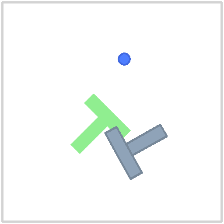


 pusht_random


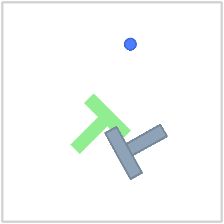


 tworoom_expert


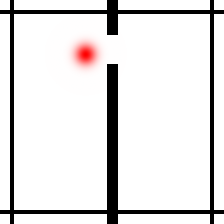


 tworoom_random


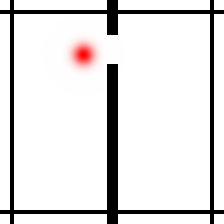


 reacher_random


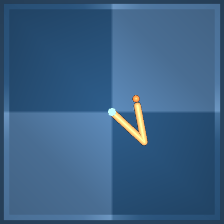

In [13]:
from IPython.display import display, Image

for cfg in SWEEP_CONFIGS:
    dirs = make_run_dirs(cfg)
    still_path = dirs["figures"] / "still_t000.png"

    print("\n", cfg["run_name"])
    if still_path.exists():
        display(Image(filename=str(still_path)))
    else:
        print("Missing:", still_path)

# Phase 3 — Load Models and Define Encoders

We load:

- LeWM checkpoint for each environment/run
- DINOv2 encoder
- MAE encoder

LeWM is environment-specific because each environment has its own checkpoint repo.
DINOv2 and MAE are shared across all runs.

In [14]:
from huggingface_hub import hf_hub_download
from transformers import AutoImageProcessor, AutoModel, ViTMAEModel, ViTConfig, ViTModel

In [15]:
# Phase 3.1 — Clone/load LeWM source once

LEWM_SRC = Path("/content/le-wm")

if not LEWM_SRC.exists():
    !git clone -q https://github.com/lucas-maes/le-wm.git /content/le-wm

if str(LEWM_SRC) not in sys.path:
    sys.path.insert(0, str(LEWM_SRC))

from jepa import JEPA
from module import ARPredictor, Embedder, MLP

print("LeWM source ready:", LEWM_SRC)

LeWM source ready: /content/le-wm


In [16]:
# Phase 3.2 — LeWM model construction

def filter_hydra(d):
    return {k: v for k, v in d.items() if not k.startswith("_")}


def vit_hf(size, patch_size, image_size, pretrained=False, use_mask_token=False):
    if size != "tiny":
        raise ValueError(f"Only LeWM tiny config is supported here, got: {size}")

    config = ViTConfig(
        image_size=image_size,
        patch_size=patch_size,
        num_channels=3,
        hidden_size=192,
        num_hidden_layers=12,
        num_attention_heads=3,
        intermediate_size=768,
    )

    return ViTModel(config, add_pooling_layer=False)


def load_lewm(checkpoint_repo):
    weights_path = hf_hub_download(repo_id=checkpoint_repo, filename="weights.pt")
    config_path = hf_hub_download(repo_id=checkpoint_repo, filename="config.json")

    with open(config_path) as f:
        cfg = json.load(f)

    encoder = vit_hf(
        size=cfg["encoder"]["size"],
        patch_size=cfg["encoder"]["patch_size"],
        image_size=cfg["encoder"]["image_size"],
        pretrained=cfg["encoder"].get("pretrained", False),
        use_mask_token=cfg["encoder"].get("use_mask_token", False),
    )

    def build_mlp(k):
        return MLP(
            input_dim=cfg[k]["input_dim"],
            output_dim=cfg[k]["output_dim"],
            hidden_dim=cfg[k]["hidden_dim"],
            norm_fn=torch.nn.BatchNorm1d,
        )

    model = JEPA(
        encoder=encoder,
        predictor=ARPredictor(**filter_hydra(cfg["predictor"])),
        action_encoder=Embedder(**filter_hydra(cfg["action_encoder"])),
        projector=build_mlp("projector"),
        pred_proj=build_mlp("pred_proj"),
    )

    state = torch.load(weights_path, map_location="cpu")
    model.load_state_dict(state, strict=True)

    return model.to(DEVICE).eval()

In [17]:
# Phase 3.3 — Load shared DINOv2 and MAE encoders

DINO_REPO = "facebook/dinov2-base"
MAE_REPO = "facebook/vit-mae-base"

dino_processor = AutoImageProcessor.from_pretrained(DINO_REPO)
dino_model = AutoModel.from_pretrained(DINO_REPO).to(DEVICE).eval()

mae_processor = AutoImageProcessor.from_pretrained(MAE_REPO)
mae_model = ViTMAEModel.from_pretrained(MAE_REPO, mask_ratio=0.0).to(DEVICE).eval()

print("Loaded DINOv2:", DINO_REPO)
print("Loaded MAE:", MAE_REPO)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

...

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/448M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTMAEModel LOAD REPORT from: facebook/vit-mae-base
Key                                                                              | Status     |  | 
---------------------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.query.bias   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.query.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.value.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.output.dense.bias      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_before.bias            | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.key.weight   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_after.bias             | UNEXPECTED |  | 
decoder.decoder_embed.bias                      

Loaded DINOv2: facebook/dinov2-base
Loaded MAE: facebook/vit-mae-base


# Phase 3.4 — Encoding Functions

Each function takes flattened image observations:

`obs_flat: (N, H, W, C)`

and returns latents:

- LeWM: `(N, 192)`
- DINOv2: `(N, 768)`
- MAE: `(N, 768)`

In [18]:
def encode_lewm(model, obs_flat, batch_size=64):
    zs = []

    with torch.no_grad():
        for i in tqdm(range(0, len(obs_flat), batch_size), desc="Encoding LeWM"):
            batch = obs_flat[i:i + batch_size]

            x = torch.tensor(batch, dtype=torch.float32, device=DEVICE) / 255.0
            x = x.permute(0, 3, 1, 2).unsqueeze(1)  # (B, 1, C, H, W)

            out = model.encode({"pixels": x})
            z = out["emb"]

            if z.ndim == 3:
                z = z.squeeze(1)

            zs.append(z.detach().cpu().float().numpy())

    return np.concatenate(zs, axis=0)

def encode_dino(obs_flat, batch_size=32):
    zs = []

    with torch.no_grad():
        for i in tqdm(range(0, len(obs_flat), batch_size), desc="Encoding DINOv2"):
            batch = obs_flat[i:i + batch_size]

            inputs = dino_processor(images=list(batch), return_tensors="pt").to(DEVICE)
            out = dino_model(**inputs)

            z = out.last_hidden_state[:, 0]  # CLS token
            zs.append(z.detach().cpu().float().numpy())

    return np.concatenate(zs, axis=0)


def encode_mae(obs_flat, batch_size=32):
    zs = []

    with torch.no_grad():
        for i in tqdm(range(0, len(obs_flat), batch_size), desc="Encoding MAE"):
            batch = obs_flat[i:i + batch_size]

            inputs = mae_processor(images=list(batch), return_tensors="pt").to(DEVICE)
            out = mae_model(**inputs)

            patch_tokens = out.last_hidden_state[:, 1:]
            z = patch_tokens.mean(dim=1)

            zs.append(z.detach().cpu().float().numpy())

    return np.concatenate(zs, axis=0)

# Phase 3.5 — Encode All Runs

This encodes every collected run. Existing latent files are reused unless `overwrite=True`.

In [19]:
def encode_run(cfg, overwrite=False):
    dirs = make_run_dirs(cfg)

    lewm_path = dirs["latents"] / "lewm_z.npy"
    dino_path = dirs["latents"] / "dino_z.npy"
    mae_path = dirs["latents"] / "mae_z.npy"

    if lewm_path.exists() and dino_path.exists() and mae_path.exists() and not overwrite:
        print(f"Loaded existing latents for {cfg['run_name']}")
        return {
            "LeWM": np.load(lewm_path),
            "DINOv2": np.load(dino_path),
            "MAE": np.load(mae_path),
        }

    obs = np.load(dirs["data"] / "obs.npy")
    T_run, E_run, H, W, C = obs.shape
    obs_flat = obs.reshape(T_run * E_run, H, W, C)

    print("\nEncoding run:", cfg["run_name"])
    print("obs_flat:", obs_flat.shape)

    lewm_model = load_lewm(cfg["checkpoint_repo"])

    lewm_z = encode_lewm(lewm_model, obs_flat)
    dino_z = encode_dino(obs_flat)
    mae_z = encode_mae(obs_flat)

    np.save(lewm_path, lewm_z)
    np.save(dino_path, dino_z)
    np.save(mae_path, mae_z)

    return {
        "LeWM": lewm_z,
        "DINOv2": dino_z,
        "MAE": mae_z,
    }

In [20]:
ENCODED_RUNS = {}

for cfg in SWEEP_CONFIGS:
    ENCODED_RUNS[cfg["run_name"]] = encode_run(cfg, overwrite=False)

print("Encoded runs:", list(ENCODED_RUNS.keys()))


Encoding run: pusht_weak
obs_flat: (800, 224, 224, 3)


weights.pt:   0%|          | 0.00/72.3M [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Encoding LeWM:   0%|          | 0/13 [00:00<?, ?it/s]

Encoding DINOv2:   0%|          | 0/25 [00:00<?, ?it/s]

...

config.json: 0.00B [00:00, ?B/s]

Encoding LeWM:   0%|          | 0/13 [00:00<?, ?it/s]

Encoding DINOv2:   0%|          | 0/25 [00:00<?, ?it/s]

Encoding MAE:   0%|          | 0/25 [00:00<?, ?it/s]

Encoded runs: ['pusht_weak', 'pusht_random', 'tworoom_expert', 'tworoom_random', 'reacher_random']


# Phase 4 — Experiment 1: Physical Content Probing

For each run and each representation, we train a Ridge linear probe from latent vectors to the saved physical-state vector.

This asks:

What physical variables are linearly decodable from each representation?

In [21]:
# Phase 4.1 — Experiment 1 function

def run_experiment_1_probe(cfg, overwrite=False):
    dirs = make_run_dirs(cfg)

    out_path = dirs["results"] / "exp1_probe_results.csv"
    if out_path.exists() and not overwrite:
        return pd.read_csv(out_path)

    states = np.load(dirs["data"] / "states.npy")
    T_run, E_run = states.shape[:2]
    y = states.reshape(T_run * E_run, -1)

    reps = {
        "LeWM": np.load(dirs["latents"] / "lewm_z.npy"),
        "DINOv2": np.load(dirs["latents"] / "dino_z.npy"),
        "MAE": np.load(dirs["latents"] / "mae_z.npy"),
    }

    rng = np.random.default_rng(0)
    reps["Random"] = rng.normal(size=(T_run * E_run, 192)).astype(np.float32)

    idx = np.arange(T_run * E_run)
    train_idx, test_idx = train_test_split(
        idx,
        test_size=0.2,
        random_state=0,
        shuffle=True,
    )

    alphas = np.logspace(-4, 4, 17)
    rows = []

    state_names = cfg.get("state_names")
    if state_names is None:
        state_names = [f"s{i}" for i in range(y.shape[1])]

    for model_name, z in reps.items():
        probe = make_pipeline(
            StandardScaler(),
            RidgeCV(alphas=alphas),
        )

        probe.fit(z[train_idx], y[train_idx])
        pred = probe.predict(z[test_idx])

        full_r2 = r2_score(y[test_idx], pred, multioutput="uniform_average")
        per_dim_r2 = r2_score(y[test_idx], pred, multioutput="raw_values")

        row = {
            "run_name": cfg["run_name"],
            "env_key": cfg["env_key"],
            "policy_type": cfg["policy_type"],
            "model": model_name,
            "full_r2": float(full_r2),
        }

        for i, name in enumerate(state_names):
            row[f"{name}_r2"] = float(per_dim_r2[i])

        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(out_path, index=False)

    save_json(
        dirs["results"] / "exp1_probe_results.json",
        {
            "config": cfg,
            "results": df.to_dict(orient="records"),
        },
    )

    return df

In [22]:
# Phase 4.2 — Run Experiment 1 for all encoded runs

EXP1_RESULTS = []

for cfg in SWEEP_CONFIGS:
    df = run_experiment_1_probe(cfg, overwrite=False)
    EXP1_RESULTS.append(df)
    print("\nDONE:", cfg["run_name"])
    display(df)

exp1_all = pd.concat(EXP1_RESULTS, ignore_index=True)
exp1_all.to_csv(AGG_DIR / "exp1_all_probe_results.csv", index=False)

print("Saved:", AGG_DIR / "exp1_all_probe_results.csv")


DONE: pusht_weak


,run_name,env_key,policy_type,model,full_r2,agent_x_r2,agent_y_r2,block_x_r2,block_y_r2,block_angle_r2,agent_vx_r2,agent_vy_r2
0,pusht_weak,pusht,weak,LeWM,0.636010,0.960746,0.956253,0.979042,0.981881,0.535653,-0.011695,0.050187
1,pusht_weak,pusht,weak,DINOv2,0.669790,0.906860,0.963150,0.932870,0.978071,0.757226,-0.018998,0.169351
2,pusht_weak,pusht,weak,MAE,0.675797,0.943825,0.968311,0.970983,0.988030,0.692095,0.039852,0.127481
3,pusht_weak,pusht,weak,Random,-0.007905,-0.006844,-0.007708,-0.009316,-0.003628,-0.007307,-0.001576,-0.018959



DONE: pusht_random


,run_name,env_key,policy_type,model,full_r2,agent_x_r2,agent_y_r2,block_x_r2,block_y_r2,block_angle_r2,agent_vx_r2,agent_vy_r2
0,pusht_random,pusht,random,LeWM,0.617702,0.782785,0.738446,0.997695,0.998277,0.990317,-0.150424,-0.033183
1,pusht_random,pusht,random,DINOv2,0.641841,0.847153,0.840409,0.987645,0.995122,0.987113,-0.102474,-0.062083
2,pusht_random,pusht,random,MAE,0.641927,0.841818,0.856271,0.998322,0.998739,0.997717,-0.123589,-0.075790
3,pusht_random,pusht,random,Random,-0.013827,-0.003104,0.003846,-0.005395,-0.012209,-0.008443,-0.072590,0.001103



DONE: tworoom_expert


...


DONE: tworoom_random


,run_name,env_key,policy_type,model,full_r2,agent_x_r2,agent_y_r2
0,tworoom_random,tworoom,random,LeWM,0.998898,0.998611,0.999186
1,tworoom_random,tworoom,random,DINOv2,0.999281,0.999044,0.999519
2,tworoom_random,tworoom,random,MAE,0.999686,0.999570,0.999802
3,tworoom_random,tworoom,random,Random,-0.007463,-0.013877,-0.001049



DONE: reacher_random


,run_name,env_key,policy_type,model,full_r2,cos_q0_or_feat0_r2,sin_q0_or_feat1_r2,cos_q1_or_feat2_r2,sin_q1_or_feat3_r2,vel_or_to_target_0_r2,vel_or_to_target_1_r2
0,reacher_random,reacher,random,LeWM,0.522360,0.532076,0.972520,0.930932,0.961597,-0.153735,-0.109228
1,reacher_random,reacher,random,DINOv2,0.501504,0.437920,0.902058,0.865494,0.957527,-0.072788,-0.081190
2,reacher_random,reacher,random,MAE,0.516752,0.501991,0.941644,0.930224,0.967805,-0.136477,-0.104673
3,reacher_random,reacher,random,Random,-0.011569,-0.011645,-0.038577,-0.000216,-0.005038,-0.016288,0.002351


Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp1_all_probe_results.csv


# Phase 5 — Experiment 3: Latent Geometry

For each run and representation, we compute whether pairwise latent distances correlate with physical-state distances.

This asks:

Does representational distance reflect physical distance?

In [23]:
# Phase 5.1 — Physical distance helpers

def get_geometry_target_array(cfg, dirs, states_flat, target_spec):
    if target_spec == "all":
        return states_flat

    if target_spec == "pusht_visible_config":
        agent_pos = states_flat[:, 0:2]
        block_pos = states_flat[:, 2:4]
        block_angle = states_flat[:, 4]

        block_angle_circ = np.stack(
            [np.sin(block_angle), np.cos(block_angle)],
            axis=1,
        )

        return np.concatenate(
            [agent_pos, block_pos, block_angle_circ],
            axis=1,
        )

    if isinstance(target_spec, list):
        return states_flat[:, target_spec]

    if isinstance(target_spec, str):
        arr = np.load(dirs["data"] / f"{target_spec}.npy")
        T_run, E_run = arr.shape[:2]
        return arr.reshape(T_run * E_run, -1)

    raise ValueError(f"Unknown geometry target spec: {target_spec}")

In [24]:
# Phase 5.2 — Experiment 3 function

def run_experiment_3_geometry(cfg, overwrite=False, num_pairs=50000):
    dirs = make_run_dirs(cfg)

    out_path = dirs["results"] / "exp3_geometry_results.csv"
    if out_path.exists() and not overwrite:
        return pd.read_csv(out_path)

    states = np.load(dirs["data"] / "states.npy")
    T_run, E_run = states.shape[:2]
    N = T_run * E_run
    states_flat = states.reshape(N, -1)

    reps = {
        "LeWM": np.load(dirs["latents"] / "lewm_z.npy"),
        "DINOv2": np.load(dirs["latents"] / "dino_z.npy"),
        "MAE": np.load(dirs["latents"] / "mae_z.npy"),
    }

    rng = np.random.default_rng(123)
    reps["Random"] = rng.normal(size=(N, 192)).astype(np.float32)

    i_idx = rng.integers(0, N, size=num_pairs)
    j_idx = rng.integers(0, N, size=num_pairs)

    mask = i_idx != j_idx
    i_idx = i_idx[mask]
    j_idx = j_idx[mask]

    def pair_dist(X):
        return np.linalg.norm(X[i_idx] - X[j_idx], axis=1)

    target_dists = {}

    for target_name, target_spec in cfg["geometry_targets"].items():
        X_target = get_geometry_target_array(cfg, dirs, states_flat, target_spec)
        X_target = StandardScaler().fit_transform(X_target)
        target_dists[target_name] = pair_dist(X_target)

    rows = []

    for model_name, z in reps.items():
        z_scaled = StandardScaler().fit_transform(z)
        dz = pair_dist(z_scaled)

        for target_name, ds in target_dists.items():
            rows.append({
                "run_name": cfg["run_name"],
                "env_key": cfg["env_key"],
                "policy_type": cfg["policy_type"],
                "model": model_name,
                "target": target_name,
                "spearman": float(spearmanr(dz, ds).correlation),
                "pearson": float(pearsonr(dz, ds).statistic),
            })

    df = pd.DataFrame(rows)
    df.to_csv(out_path, index=False)

    save_json(
        dirs["results"] / "exp3_geometry_results.json",
        {
            "config": cfg,
            "results": df.to_dict(orient="records"),
        },
    )

    return df

In [25]:
# Phase 5.3 — Run Experiment 3 for all encoded runs

EXP3_RESULTS = []

for cfg in SWEEP_CONFIGS:
    df = run_experiment_3_geometry(cfg, overwrite=False)
    EXP3_RESULTS.append(df)
    print("\nDONE:", cfg["run_name"])
    display(df)

exp3_all = pd.concat(EXP3_RESULTS, ignore_index=True)
exp3_all.to_csv(AGG_DIR / "exp3_all_geometry_results.csv", index=False)

print("Saved:", AGG_DIR / "exp3_all_geometry_results.csv")


DONE: pusht_weak


,run_name,env_key,policy_type,model,target,spearman,pearson
0,pusht_weak,pusht,weak,LeWM,agent_pos,0.719258,0.718724
1,pusht_weak,pusht,weak,LeWM,block_pos,0.752076,0.766604
2,pusht_weak,pusht,weak,LeWM,visible_config,0.700213,0.729813
3,pusht_weak,pusht,weak,LeWM,full_state,0.624116,0.628126
4,pusht_weak,pusht,weak,DINOv2,agent_pos,0.285527,0.318685
5,pusht_weak,pusht,weak,DINOv2,block_pos,0.292894,0.342850
6,pusht_weak,pusht,weak,DINOv2,visible_config,0.314020,0.375328
7,pusht_weak,pusht,weak,DINOv2,full_state,0.264050,0.304785
8,pusht_weak,pusht,weak,MAE,agent_pos,0.272261,0.317679
9,pusht_weak,pusht,weak,MAE,block_pos,0.284387,0.348034



DONE: pusht_random


,run_name,env_key,policy_type,model,target,spearman,pearson
0,pusht_random,pusht,random,LeWM,agent_pos,0.146707,0.197528
1,pusht_random,pusht,random,LeWM,block_pos,0.672189,0.659839
2,pusht_random,pusht,random,LeWM,visible_config,0.482263,0.586646
3,pusht_random,pusht,random,LeWM,full_state,0.528543,0.548633
4,pusht_random,pusht,random,DINOv2,agent_pos,0.395328,0.386987
5,pusht_random,pusht,random,DINOv2,block_pos,0.321207,0.513013
6,pusht_random,pusht,random,DINOv2,visible_config,0.462919,0.671626
7,pusht_random,pusht,random,DINOv2,full_state,0.329516,0.434456
8,pusht_random,pusht,random,MAE,agent_pos,0.351070,0.364638
9,pusht_random,pusht,random,MAE,block_pos,0.487925,0.662775



DONE: tworoom_expert


...


DONE: tworoom_random


,run_name,env_key,policy_type,model,target,spearman,pearson
0,tworoom_random,tworoom,random,LeWM,agent_pos,0.485111,0.530936
1,tworoom_random,tworoom,random,LeWM,full_state,0.485111,0.530936
2,tworoom_random,tworoom,random,DINOv2,agent_pos,0.709069,0.670076
3,tworoom_random,tworoom,random,DINOv2,full_state,0.709069,0.670076
4,tworoom_random,tworoom,random,MAE,agent_pos,0.836014,0.776651
5,tworoom_random,tworoom,random,MAE,full_state,0.836014,0.776651
6,tworoom_random,tworoom,random,Random,agent_pos,-0.007341,-0.006202
7,tworoom_random,tworoom,random,Random,full_state,-0.007341,-0.006202



DONE: reacher_random


,run_name,env_key,policy_type,model,target,spearman,pearson
0,reacher_random,reacher,random,LeWM,qpos,0.145437,0.190115
1,reacher_random,reacher,random,LeWM,qvel,-0.005894,0.001209
2,reacher_random,reacher,random,LeWM,target_pos,0.051747,0.155594
3,reacher_random,reacher,random,LeWM,finger_pos,0.219809,0.328280
4,reacher_random,reacher,random,LeWM,full_state,0.131256,0.227570
5,reacher_random,reacher,random,DINOv2,qpos,0.162101,0.188162
6,reacher_random,reacher,random,DINOv2,qvel,0.001173,-0.000409
7,reacher_random,reacher,random,DINOv2,target_pos,0.201136,0.215112
8,reacher_random,reacher,random,DINOv2,finger_pos,0.247264,0.275411
9,reacher_random,reacher,random,DINOv2,full_state,0.161352,0.203875


Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp3_all_geometry_results.csv


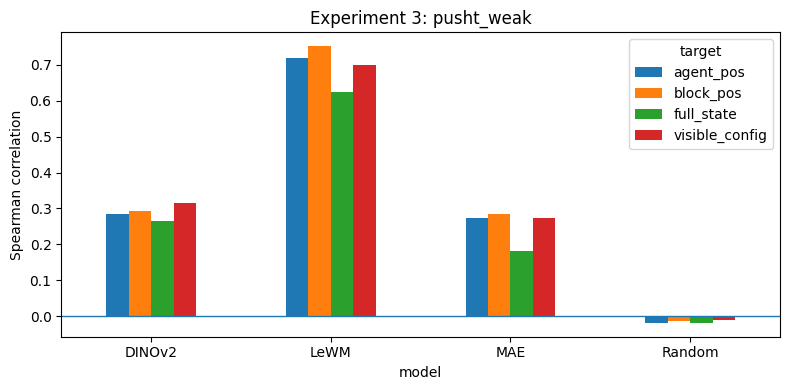

Saved: /content/drive/MyDrive/stablewm_sweep_project/sweeps/pusht_weak/figures/exp3_geometry.png


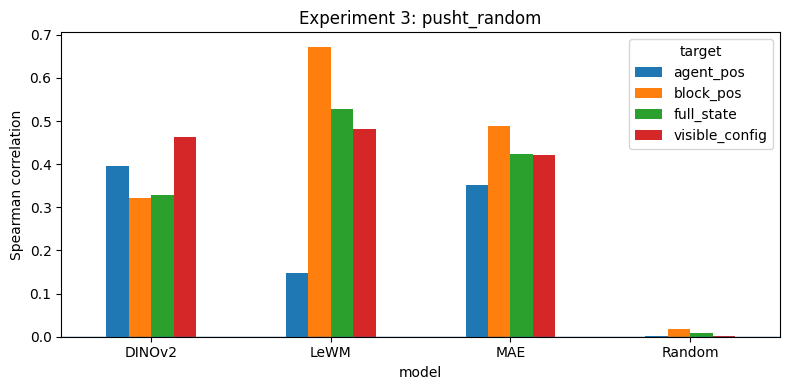

Saved: /content/drive/MyDrive/stablewm_sweep_project/sweeps/pusht_random/figures/exp3_geometry.png


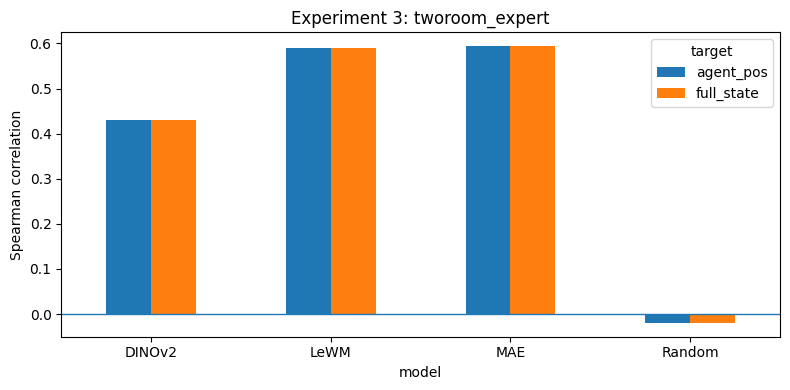

Saved: /content/drive/MyDrive/stablewm_sweep_project/sweeps/tworoom_expert/figures/exp3_geometry.png


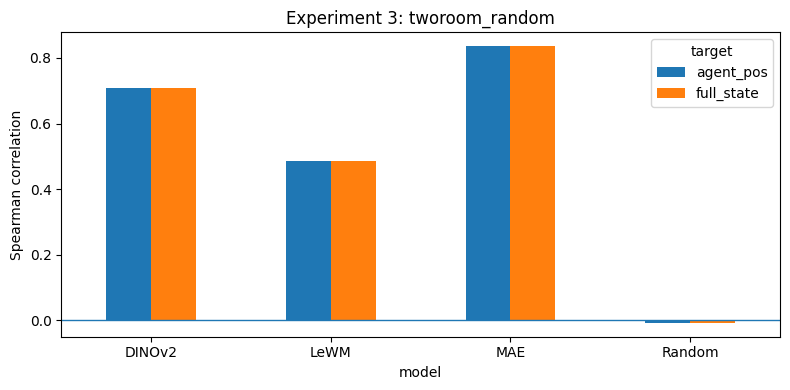

Saved: /content/drive/MyDrive/stablewm_sweep_project/sweeps/tworoom_random/figures/exp3_geometry.png


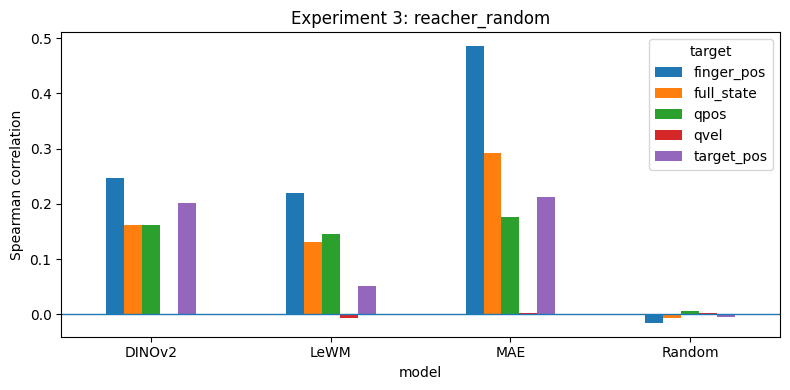

Saved: /content/drive/MyDrive/stablewm_sweep_project/sweeps/reacher_random/figures/exp3_geometry.png


In [26]:
# Phase 5.4 — Plot Experiment 3 per run

for cfg in SWEEP_CONFIGS:
    dirs = make_run_dirs(cfg)
    df = pd.read_csv(dirs["results"] / "exp3_geometry_results.csv")

    plot_df = df.pivot(index="model", columns="target", values="spearman")

    ax = plot_df.plot(kind="bar", figsize=(8, 4))
    ax.set_ylabel("Spearman correlation")
    ax.set_title(f"Experiment 3: {cfg['run_name']}")
    ax.axhline(0, linewidth=1)
    plt.xticks(rotation=0)
    plt.tight_layout()

    out_path = dirs["figures"] / "exp3_geometry.png"
    plt.savefig(out_path, dpi=200)
    plt.show()

    print("Saved:", out_path)

In [27]:
def summarize_goal_distances(cfg):
    dirs = make_run_dirs(cfg)
    states = np.load(dirs["data"] / "states.npy")

    print("\n", cfg["run_name"])
    print("states:", states.shape)

    if cfg["env_key"] == "tworoom":
        # Need separately collected goal_state if not saved yet.
        print("TwoRoom needs goal_state saved during rollout.")

    elif cfg["env_key"] == "pusht":
        # agent position vs block position; block position vs implicit goal approx center
        agent_pos = states[..., 0:2]
        block_pos = states[..., 2:4]
        agent_block_dist = np.linalg.norm(agent_pos - block_pos, axis=-1)
        print("agent-block dist mean/min/max:", agent_block_dist.mean(), agent_block_dist.min(), agent_block_dist.max())

    elif cfg["env_key"] == "reacher":
        dirs = make_run_dirs(cfg)
        finger = np.load(dirs["data"] / "finger_pos.npy")
        target = np.load(dirs["data"] / "target_pos.npy")
        dist = np.linalg.norm(finger - target, axis=-1)
        print("finger-target dist mean/min/max:", dist.mean(), dist.min(), dist.max())


for cfg in SWEEP_CONFIGS:
    summarize_goal_distances(cfg)


 pusht_weak
states: (100, 8, 7)
agent-block dist mean/min/max: 46.37217218247058 3.376528030360582 222.60994837285097

 pusht_random
states: (100, 8, 7)
agent-block dist mean/min/max: 264.782905969285 55.55832836935357 548.0734064121759

 tworoom_expert
states: (100, 8, 2)
TwoRoom needs goal_state saved during rollout.

 tworoom_random
states: (100, 8, 2)
TwoRoom needs goal_state saved during rollout.

 reacher_random
states: (100, 8, 6)
finger-target dist mean/min/max: 0.256760585204342 0.04019462771839175 0.4199469305195618


# Phase 6 — Experiment 5A: Matched Predictor Violation-of-Expectation

For each run and each representation, we train the same Ridge transition predictor:

latent history + action history → future latent

Then we evaluate prediction error against four targets:

1. normal future
2. near physical violation
3. far physical violation
4. random target

This tests whether each representation supports expectation-like predictive structure.

In [28]:
def get_voe_physical_features(cfg, dirs):
    states = np.load(dirs["data"] / "states.npy")
    T_run, E_run = states.shape[:2]
    states_flat = states.reshape(T_run * E_run, -1)

    if cfg["env_key"] == "pusht":
        agent_pos = states_flat[:, 0:2]
        block_pos = states_flat[:, 2:4]
        block_angle = states_flat[:, 4]

        angle_circ = np.stack(
            [np.sin(block_angle), np.cos(block_angle)],
            axis=1,
        )

        return np.concatenate(
            [agent_pos, block_pos, angle_circ],
            axis=1,
        )

    if cfg["env_key"] == "tworoom":
        goals = np.load(dirs["data"] / "goal_state.npy")
        goals_flat = goals.reshape(T_run * E_run, -1)

        # Use both agent and goal so counterfactuals respect task context.
        return np.concatenate([states_flat, goals_flat], axis=1)

    if cfg["env_key"] == "reacher":
        qpos = np.load(dirs["data"] / "qpos.npy").reshape(T_run * E_run, -1)
        finger_pos = np.load(dirs["data"] / "finger_pos.npy").reshape(T_run * E_run, -1)
        target_pos = np.load(dirs["data"] / "target_pos.npy").reshape(T_run * E_run, -1)

        # Exclude qvel; it was weakly represented and adds noise.
        return np.concatenate([qpos, finger_pos, target_pos], axis=1)

    raise ValueError(f"Unknown env_key: {cfg['env_key']}")

In [29]:
def make_action_blocks(actions, block_size):
    """
    actions: (T, E, A)
    returns: (T - block_size + 1, E, block_size * A)
    """
    T_run, E_run, A = actions.shape
    blocks = []

    for t in range(T_run - block_size + 1):
        block = actions[t:t + block_size]          # (B, E, A)
        block = np.transpose(block, (1, 0, 2))     # (E, B, A)
        block = block.reshape(E_run, block_size * A)
        blocks.append(block)

    return np.asarray(blocks).astype(np.float32)

In [30]:
def build_prediction_windows(cfg, dirs, z_seq):
    """
    z_seq: (T, E, D)

    Returns:
    emb_windows: (B, H, D)
    act_windows: (B, H, action_block * action_dim)
    targets: (B, D)
    target_indices: (B,)
    target_times: (B,)
    target_envs: (B,)
    """

    actions = np.load(dirs["data"] / "actions.npy")
    terminateds = np.load(dirs["data"] / "terminateds.npy")
    truncateds = np.load(dirs["data"] / "truncateds.npy")

    done = np.logical_or(terminateds, truncateds)  # (T, E)

    T_run, E_run = actions.shape[:2]
    H = cfg["history_size"]
    B = cfg["action_block"]

    action_blocks = make_action_blocks(actions, B)

    emb_windows = []
    act_windows = []
    targets = []
    target_indices = []
    target_times = []
    target_envs = []

    max_start = T_run - H * B

    for t in range(max_start):
        frame_times = [t + k * B for k in range(H)]
        action_times = [t + k * B for k in range(H)]
        target_time = t + H * B

        for e in range(E_run):
            # Exclude windows crossing episode boundaries/resets.
            if done[t:target_time + 1, e].any():
                continue

            emb_windows.append(z_seq[frame_times, e])
            act_windows.append(action_blocks[action_times, e])
            targets.append(z_seq[target_time, e])

            target_indices.append(target_time * E_run + e)
            target_times.append(target_time)
            target_envs.append(e)

    return {
        "emb_windows": np.asarray(emb_windows),
        "act_windows": np.asarray(act_windows),
        "targets": np.asarray(targets),
        "target_indices": np.asarray(target_indices),
        "target_times": np.asarray(target_times),
        "target_envs": np.asarray(target_envs),
    }

In [31]:
def choose_counterfactual_targets(physical_features, target_indices, seed=123):
    physical = StandardScaler().fit_transform(physical_features)

    rng = np.random.default_rng(seed)

    near_indices = []
    far_indices = []
    random_indices = []

    N = physical.shape[0]

    for true_idx in target_indices:
        d = np.linalg.norm(physical - physical[true_idx], axis=1)
        d[true_idx] = np.inf

        finite = d[np.isfinite(d)]

        near_low, near_high = np.percentile(finite, [45, 55])
        near_pool = np.where((d >= near_low) & (d <= near_high))[0]

        far_thresh = np.percentile(finite, 90)
        far_pool = np.where(d >= far_thresh)[0]

        near_indices.append(rng.choice(near_pool))
        far_indices.append(rng.choice(far_pool))

        r = rng.integers(0, N)
        while r == true_idx:
            r = rng.integers(0, N)
        random_indices.append(r)

    return {
        "near": np.asarray(near_indices),
        "far": np.asarray(far_indices),
        "random": np.asarray(random_indices),
    }

In [32]:
def run_experiment_5_voe(cfg, overwrite=False):
    dirs = make_run_dirs(cfg)

    summary_path = dirs["results"] / "exp5_voe_summary.csv"
    effects_path = dirs["results"] / "exp5_voe_effects.csv"

    if summary_path.exists() and effects_path.exists() and not overwrite:
        return pd.read_csv(summary_path), pd.read_csv(effects_path)

    states = np.load(dirs["data"] / "states.npy")
    T_run, E_run = states.shape[:2]

    reps = {
        "LeWM": np.load(dirs["latents"] / "lewm_z.npy").reshape(T_run, E_run, -1),
        "DINOv2": np.load(dirs["latents"] / "dino_z.npy").reshape(T_run, E_run, -1),
        "MAE": np.load(dirs["latents"] / "mae_z.npy").reshape(T_run, E_run, -1),
    }

    rng = np.random.default_rng(0)
    reps["Random"] = rng.normal(size=reps["LeWM"].shape).astype(np.float32)

    physical_features = get_voe_physical_features(cfg, dirs)

    summary_rows = []
    score_rows = []

    alphas = np.logspace(-4, 4, 17)

    for model_name, z_seq in reps.items():
        pack = build_prediction_windows(cfg, dirs, z_seq)

        emb_windows = pack["emb_windows"]
        act_windows = pack["act_windows"]
        targets = pack["targets"]
        target_indices = pack["target_indices"]
        target_times = pack["target_times"]

        if len(targets) < 20:
            raise RuntimeError(
                f"Too few valid prediction windows for {cfg['run_name']} / {model_name}: {len(targets)}"
            )

        Bn, H, D = emb_windows.shape

        X_lat = emb_windows.reshape(Bn, H * D)
        X_act = act_windows.reshape(Bn, -1)
        X = np.concatenate([X_lat, X_act], axis=1)
        y = targets

        # Prefer temporal split if enough samples exist.
        cutoff = int(0.75 * cfg["T"])
        train_mask = target_times < cutoff
        test_mask = target_times >= cutoff

        if train_mask.sum() < 20 or test_mask.sum() < 20:
            idx = np.arange(Bn)
            train_idx, test_idx = train_test_split(
                idx,
                test_size=0.25,
                random_state=0,
                shuffle=True,
            )
        else:
            train_idx = np.where(train_mask)[0]
            test_idx = np.where(test_mask)[0]

        predictor = make_pipeline(
            StandardScaler(),
            RidgeCV(alphas=alphas),
        )

        print(f"Training Exp5 predictor: {cfg['run_name']} / {model_name}")
        predictor.fit(X[train_idx], y[train_idx])

        pred = predictor.predict(X[test_idx])

        z_flat = z_seq.reshape(T_run * E_run, -1)
        cf = choose_counterfactual_targets(
            physical_features,
            target_indices,
            seed=123,
        )

        condition_targets = {
            "normal": targets,
            "near_violation": z_flat[cf["near"]],
            "far_violation": z_flat[cf["far"]],
            "random_target": z_flat[cf["random"]],
        }

        condition_surprises = {}

        for condition, all_condition_targets in condition_targets.items():
            y_target = all_condition_targets[test_idx]
            surprise = np.linalg.norm(pred - y_target, axis=1)
            condition_surprises[condition] = surprise

            summary_rows.append({
                "run_name": cfg["run_name"],
                "env_key": cfg["env_key"],
                "policy_type": cfg["policy_type"],
                "model": model_name,
                "condition": condition,
                "mean_surprise": float(surprise.mean()),
                "std_surprise": float(surprise.std()),
                "median_surprise": float(np.median(surprise)),
                "num_windows": int(len(surprise)),
            })

            for s in surprise:
                score_rows.append({
                    "run_name": cfg["run_name"],
                    "env_key": cfg["env_key"],
                    "policy_type": cfg["policy_type"],
                    "model": model_name,
                    "condition": condition,
                    "surprise": float(s),
                })

    summary_df = pd.DataFrame(summary_rows)
    scores_df = pd.DataFrame(score_rows)

    summary_df.to_csv(summary_path, index=False)
    scores_df.to_csv(dirs["results"] / "exp5_voe_scores.csv", index=False)

    effects_rows = []

    for (run_name, model), sub in summary_df.groupby(["run_name", "model"]):
        vals = sub.set_index("condition")["mean_surprise"]

        normal = vals["normal"]
        near = vals["near_violation"]
        far = vals["far_violation"]
        random_t = vals["random_target"]

        effects_rows.append({
            "run_name": run_name,
            "env_key": cfg["env_key"],
            "policy_type": cfg["policy_type"],
            "model": model,
            "near_minus_normal": float(near - normal),
            "far_minus_normal": float(far - normal),
            "random_minus_normal": float(random_t - normal),
            "near_over_normal": float(near / normal),
            "far_over_normal": float(far / normal),
            "random_over_normal": float(random_t / normal),
            "far_minus_near": float(far - near),
            "far_minus_random": float(far - random_t),
        })

    effects_df = pd.DataFrame(effects_rows)
    effects_df.to_csv(effects_path, index=False)

    save_json(
        dirs["results"] / "exp5_voe_results.json",
        {
            "config": cfg,
            "summary": summary_df.to_dict(orient="records"),
            "effects": effects_df.to_dict(orient="records"),
        },
    )

    return summary_df, effects_df

In [33]:
EXP5_SUMMARIES = []
EXP5_EFFECTS = []

for cfg in SWEEP_CONFIGS:
    summary_df, effects_df = run_experiment_5_voe(cfg, overwrite=False)

    EXP5_SUMMARIES.append(summary_df)
    EXP5_EFFECTS.append(effects_df)

    print("\nDONE:", cfg["run_name"])
    display(summary_df)
    display(effects_df)

exp5_summary_all = pd.concat(EXP5_SUMMARIES, ignore_index=True)
exp5_effects_all = pd.concat(EXP5_EFFECTS, ignore_index=True)

exp5_summary_all.to_csv(AGG_DIR / "exp5_all_voe_summary.csv", index=False)
exp5_effects_all.to_csv(AGG_DIR / "exp5_all_voe_effects.csv", index=False)

print("Saved:")
print(AGG_DIR / "exp5_all_voe_summary.csv")
print(AGG_DIR / "exp5_all_voe_effects.csv")

Training Exp5 predictor: pusht_weak / LeWM
Training Exp5 predictor: pusht_weak / DINOv2
Training Exp5 predictor: pusht_weak / MAE
Training Exp5 predictor: pusht_weak / Random

DONE: pusht_weak


,run_name,env_key,policy_type,model,condition,mean_surprise,std_surprise,median_surprise,num_windows
0,pusht_weak,pusht,weak,LeWM,normal,0.527592,0.264631,0.442464,192
1,pusht_weak,pusht,weak,LeWM,near_violation,1.319762,0.291539,1.328640,192
2,pusht_weak,pusht,weak,LeWM,far_violation,1.737827,0.325274,1.721798,192
3,pusht_weak,pusht,weak,LeWM,random_target,1.324087,0.447719,1.351849,192
4,pusht_weak,pusht,weak,DINOv2,normal,15.998084,7.121532,14.674844,192
5,pusht_weak,pusht,weak,DINOv2,near_violation,20.673052,4.876063,19.497436,192
6,pusht_weak,pusht,weak,DINOv2,far_violation,23.895059,5.979522,23.461551,192
7,pusht_weak,pusht,weak,DINOv2,random_target,20.960827,5.514000,20.342454,192
8,pusht_weak,pusht,weak,MAE,normal,0.588819,0.217718,0.574713,192
9,pusht_weak,pusht,weak,MAE,near_violation,1.003379,0.258457,0.949577,192


,run_name,env_key,policy_type,model,near_minus_normal,far_minus_normal,random_minus_normal,near_over_normal,far_over_normal,random_over_normal,far_minus_near,far_minus_random
0,pusht_weak,pusht,weak,DINOv2,4.674969,7.896975,4.962744,1.292221,1.493620,1.310209,3.222006,2.934231
1,pusht_weak,pusht,weak,LeWM,0.792170,1.210235,0.796494,2.501482,3.293883,2.509678,0.418065,0.413741
2,pusht_weak,pusht,weak,MAE,0.414561,0.474602,0.355493,1.704055,1.806025,1.603739,0.060042,0.119109
3,pusht_weak,pusht,weak,Random,-0.055891,-0.145933,-0.163177,0.995992,0.989535,0.988299,-0.090042,0.017244


Training Exp5 predictor: pusht_random / LeWM
Training Exp5 predictor: pusht_random / DINOv2
Training Exp5 predictor: pusht_random / MAE
Training Exp5 predictor: pusht_random / Random

DONE: pusht_random


,run_name,env_key,policy_type,model,condition,mean_surprise,std_surprise,median_surprise,num_windows
0,pusht_random,pusht,random,LeWM,normal,0.209405,0.123717,0.174255,192
1,pusht_random,pusht,random,LeWM,near_violation,1.053702,0.327866,1.085144,192
2,pusht_random,pusht,random,LeWM,far_violation,1.134619,0.300001,1.179413,192
3,pusht_random,pusht,random,LeWM,random_target,0.926952,0.419045,0.984938,192
4,pusht_random,pusht,random,DINOv2,normal,4.623758,2.918764,4.809154,192
5,pusht_random,pusht,random,DINOv2,near_violation,18.432638,3.720670,18.397487,192
6,pusht_random,pusht,random,DINOv2,far_violation,19.523210,3.455887,19.299101,192
7,pusht_random,pusht,random,DINOv2,random_target,16.547820,5.369968,17.379115,192
8,pusht_random,pusht,random,MAE,normal,0.204761,0.126554,0.182152,192
9,pusht_random,pusht,random,MAE,near_violation,1.019753,0.252725,0.967213,192


...

,run_name,env_key,policy_type,model,near_minus_normal,far_minus_normal,random_minus_normal,near_over_normal,far_over_normal,random_over_normal,far_minus_near,far_minus_random
0,tworoom_random,tworoom,random,DINOv2,3.785489,7.445923,4.252656,1.814112,2.601329,1.914581,3.660433,3.193267
1,tworoom_random,tworoom,random,LeWM,8.484608,8.983505,6.906926,1.879541,1.931259,1.715994,0.498897,2.076579
2,tworoom_random,tworoom,random,MAE,0.116551,0.209980,0.124614,1.939807,2.693172,2.004827,0.093429,0.085366
3,tworoom_random,tworoom,random,Random,-0.112532,-0.102759,-0.161655,0.991929,0.992630,0.988406,0.009773,0.058897


Training Exp5 predictor: reacher_random / LeWM
Training Exp5 predictor: reacher_random / DINOv2
Training Exp5 predictor: reacher_random / MAE
Training Exp5 predictor: reacher_random / Random

DONE: reacher_random


,run_name,env_key,policy_type,model,condition,mean_surprise,std_surprise,median_surprise,num_windows
0,reacher_random,reacher,random,LeWM,normal,1.579877,0.963884,1.253320,192
1,reacher_random,reacher,random,LeWM,near_violation,2.575086,0.894053,2.457089,192
2,reacher_random,reacher,random,LeWM,far_violation,2.514289,0.694366,2.460921,192
3,reacher_random,reacher,random,LeWM,random_target,2.415837,0.932642,2.438978,192
4,reacher_random,reacher,random,DINOv2,normal,12.874164,3.828457,12.195261,192
5,reacher_random,reacher,random,DINOv2,near_violation,17.399118,3.426707,17.213545,192
6,reacher_random,reacher,random,DINOv2,far_violation,17.593663,3.714789,17.296784,192
7,reacher_random,reacher,random,DINOv2,random_target,17.020118,3.838523,17.226041,192
8,reacher_random,reacher,random,MAE,normal,0.463887,0.127478,0.461194,192
9,reacher_random,reacher,random,MAE,near_violation,0.633470,0.106129,0.632993,192


,run_name,env_key,policy_type,model,near_minus_normal,far_minus_normal,random_minus_normal,near_over_normal,far_over_normal,random_over_normal,far_minus_near,far_minus_random
0,reacher_random,reacher,random,DINOv2,4.524953,4.719499,4.145954,1.351476,1.366587,1.322037,0.194545,0.573544
1,reacher_random,reacher,random,LeWM,0.995209,0.934412,0.835960,1.629928,1.591446,1.529130,-0.060797,0.098452
2,reacher_random,reacher,random,MAE,0.169582,0.180563,0.162323,1.365568,1.389239,1.349919,0.010981,0.018240
3,reacher_random,reacher,random,Random,-0.131226,-0.175924,-0.161655,0.990589,0.987383,0.988406,-0.044698,-0.014268


Saved:
/content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_all_voe_summary.csv
/content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_all_voe_effects.csv


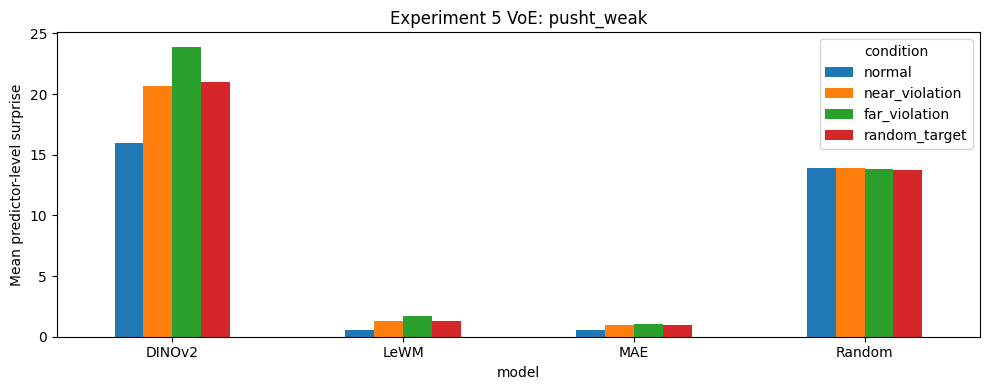

Saved: /content/drive/MyDrive/stablewm_sweep_project/sweeps/pusht_weak/figures/exp5_voe_conditions.png


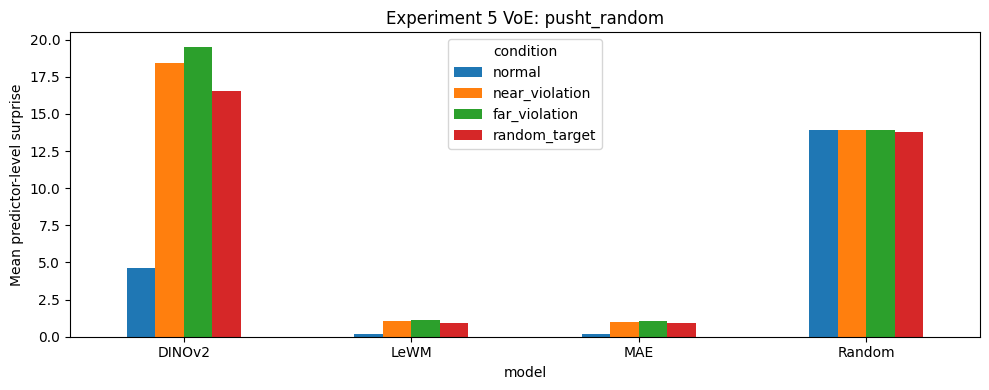

Saved: /content/drive/MyDrive/stablewm_sweep_project/sweeps/pusht_random/figures/exp5_voe_conditions.png


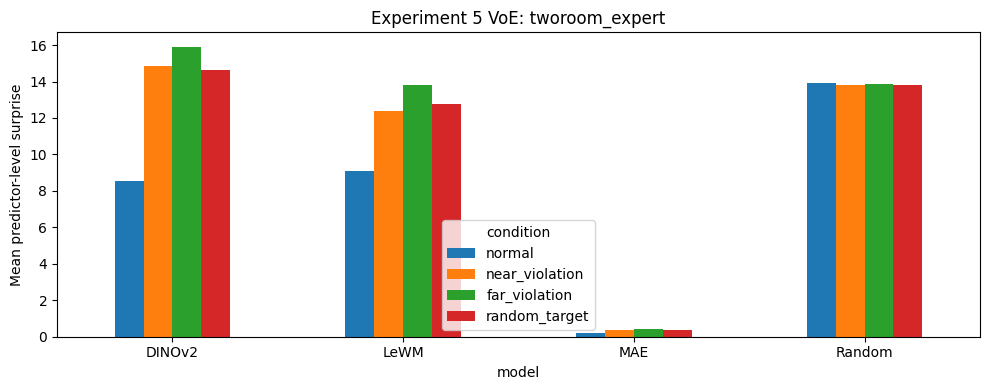

Saved: /content/drive/MyDrive/stablewm_sweep_project/sweeps/tworoom_expert/figures/exp5_voe_conditions.png


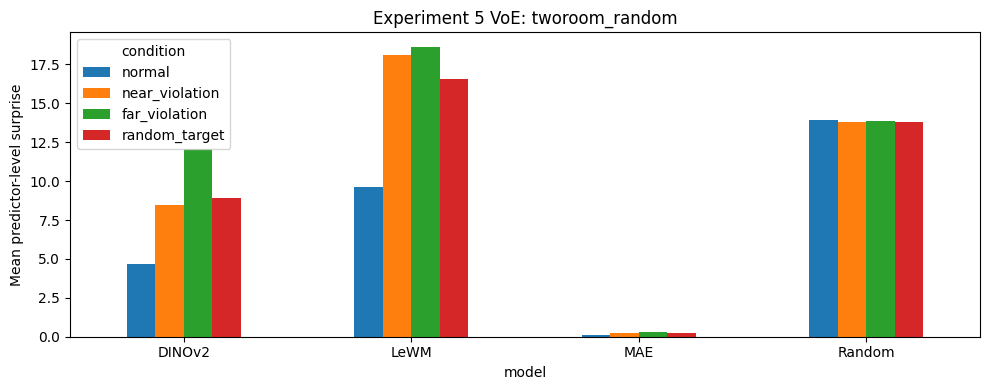

Saved: /content/drive/MyDrive/stablewm_sweep_project/sweeps/tworoom_random/figures/exp5_voe_conditions.png


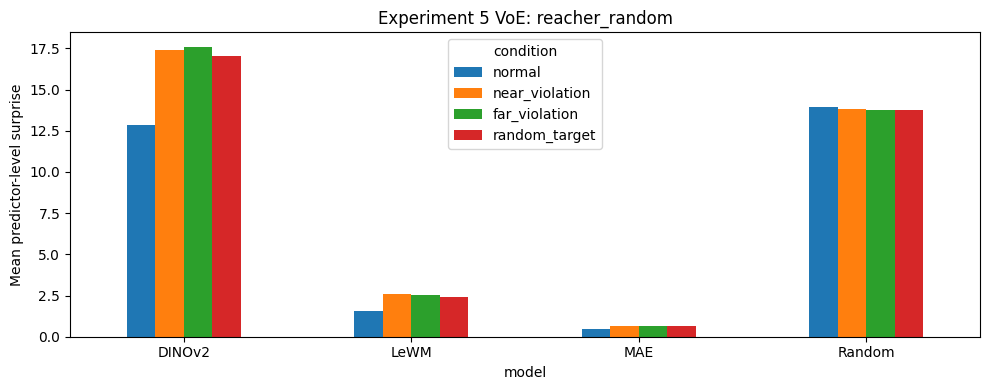

Saved: /content/drive/MyDrive/stablewm_sweep_project/sweeps/reacher_random/figures/exp5_voe_conditions.png


In [34]:
for cfg in SWEEP_CONFIGS:
    dirs = make_run_dirs(cfg)
    df = pd.read_csv(dirs["results"] / "exp5_voe_summary.csv")

    plot_df = df.pivot(
        index="model",
        columns="condition",
        values="mean_surprise",
    )

    condition_order = ["normal", "near_violation", "far_violation", "random_target"]
    plot_df = plot_df[condition_order]

    ax = plot_df.plot(kind="bar", figsize=(10, 4))
    ax.set_ylabel("Mean predictor-level surprise")
    ax.set_title(f"Experiment 5 VoE: {cfg['run_name']}")
    plt.xticks(rotation=0)
    plt.tight_layout()

    out_path = dirs["figures"] / "exp5_voe_conditions.png"
    plt.savefig(out_path, dpi=200)
    plt.show()

    print("Saved:", out_path)

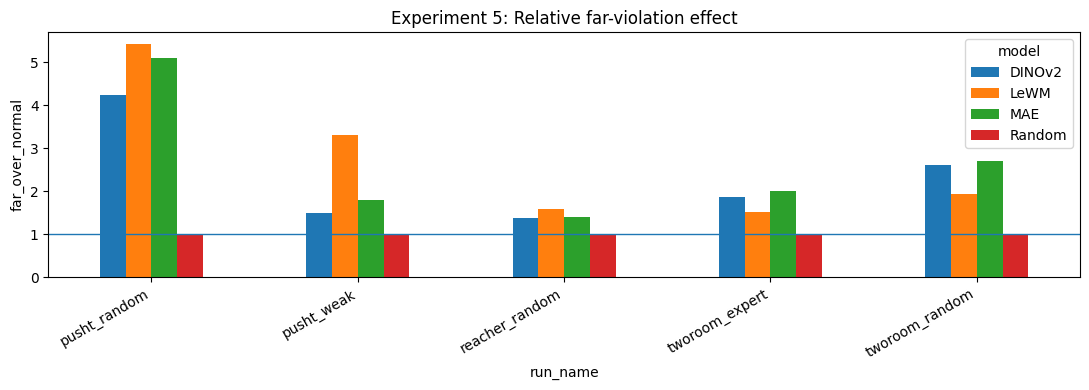

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_far_over_normal_by_run.png


In [35]:
effect_metric = "far_over_normal"

plot_df = exp5_effects_all.pivot_table(
    index="run_name",
    columns="model",
    values=effect_metric,
)

ax = plot_df.plot(kind="bar", figsize=(11, 4))
ax.set_ylabel(effect_metric)
ax.set_title("Experiment 5: Relative far-violation effect")
ax.axhline(1.0, linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

out_path = AGG_DIR / "exp5_far_over_normal_by_run.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

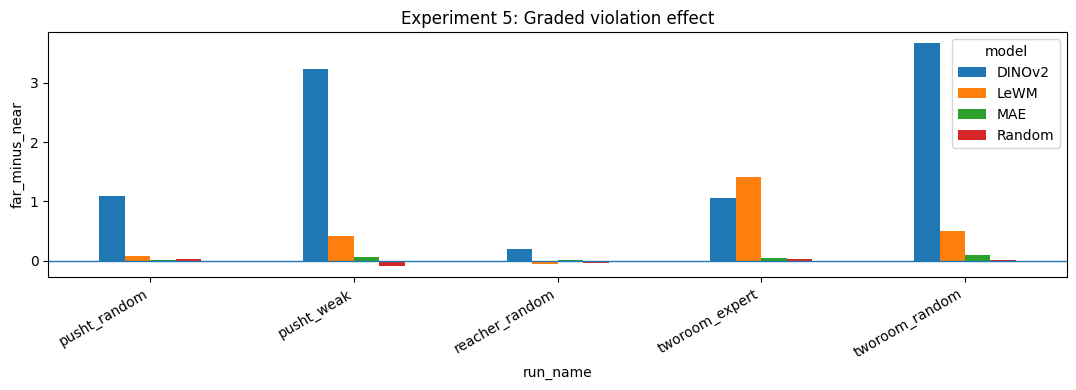

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_far_minus_near_by_run.png


In [36]:
effect_metric = "far_minus_near"

plot_df = exp5_effects_all.pivot_table(
    index="run_name",
    columns="model",
    values=effect_metric,
)

ax = plot_df.plot(kind="bar", figsize=(11, 4))
ax.set_ylabel(effect_metric)
ax.set_title("Experiment 5: Graded violation effect")
ax.axhline(0.0, linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

out_path = AGG_DIR / "exp5_far_minus_near_by_run.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

# Phase 7 — Stabilizing Experiment 5

This phase checks whether the VoE results are stable.

We do three things:

1. Bootstrap confidence intervals for Exp 5 effects.
2. Sweep prediction horizon.
3. Sweep near/far violation thresholds.

The goal is to verify that the main qualitative pattern is not an artifact of one hyperparameter setting.

In [42]:
# Phase 7.1 — Bootstrap CIs for Exp 5 effects

def bootstrap_mean_ci(values, n_boot=2000, ci=95, seed=0):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)

    boots = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boots.append(sample.mean())

    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)

    return float(values.mean()), float(lo), float(hi)


def bootstrap_exp5_effects(scores_df, n_boot=2000, seed=0):
    rows = []

    group_cols = ["run_name", "env_key", "policy_type", "model"]

    for keys, sub in scores_df.groupby(group_cols):
        run_name, env_key, policy_type, model = keys

        piv = {
            cond: sub[sub["condition"] == cond]["surprise"].values
            for cond in sub["condition"].unique()
        }

        normal = piv["normal"]
        near = piv["near_violation"]
        far = piv["far_violation"]
        random_t = piv["random_target"]

        rng = np.random.default_rng(seed)
        n = min(len(normal), len(near), len(far), len(random_t))

        metrics = {
            "near_minus_normal": near[:n] - normal[:n],
            "far_minus_normal": far[:n] - normal[:n],
            "random_minus_normal": random_t[:n] - normal[:n],
            "near_over_normal": near[:n] / normal[:n],
            "far_over_normal": far[:n] / normal[:n],
            "random_over_normal": random_t[:n] / normal[:n],
            "far_minus_near": far[:n] - near[:n],
            "far_minus_random": far[:n] - random_t[:n],
        }

        for metric_name, vals in metrics.items():
            mean, lo, hi = bootstrap_mean_ci(
                vals,
                n_boot=n_boot,
                ci=95,
                seed=seed,
            )

            rows.append({
                "run_name": run_name,
                "env_key": env_key,
                "policy_type": policy_type,
                "model": model,
                "metric": metric_name,
                "mean": mean,
                "ci_low": lo,
                "ci_high": hi,
                "n": int(n),
            })

    return pd.DataFrame(rows)

In [43]:
# Load all Exp 5 score files and bootstrap

exp5_score_dfs = []

for cfg in SWEEP_CONFIGS:
    dirs = make_run_dirs(cfg)
    path = dirs["results"] / "exp5_voe_scores.csv"

    df = pd.read_csv(path)
    exp5_score_dfs.append(df)

exp5_scores_all = pd.concat(exp5_score_dfs, ignore_index=True)

exp5_bootstrap_ci = bootstrap_exp5_effects(
    exp5_scores_all,
    n_boot=2000,
    seed=0,
)

exp5_bootstrap_ci.to_csv(AGG_DIR / "exp5_bootstrap_ci.csv", index=False)

display(exp5_bootstrap_ci)
print("Saved:", AGG_DIR / "exp5_bootstrap_ci.csv")

,run_name,env_key,policy_type,model,metric,mean,ci_low,ci_high,n
0,pusht_random,pusht,random,DINOv2,near_minus_normal,13.808880,13.051513,14.602242,192
1,pusht_random,pusht,random,DINOv2,far_minus_normal,14.899453,14.116687,15.713329,192
2,pusht_random,pusht,random,DINOv2,random_minus_normal,11.924062,10.968694,12.892847,192
3,pusht_random,pusht,random,DINOv2,near_over_normal,9.001785,7.598204,10.505112,192
4,pusht_random,pusht,random,DINOv2,far_over_normal,9.549955,8.062380,11.177336,192
...,...,...,...,...,...,...,...,...,...
155,tworoom_random,tworoom,random,Random,near_over_normal,0.994015,0.984526,1.003251,192
156,tworoom_random,tworoom,random,Random,far_over_normal,0.995049,0.984506,1.005304,192
157,tworoom_random,tworoom,random,Random,random_over_normal,0.990489,0.981169,0.999944,192
158,tworoom_random,tworoom,random,Random,far_minus_near,0.009773,-0.116756,0.141590,192


Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_bootstrap_ci.csv


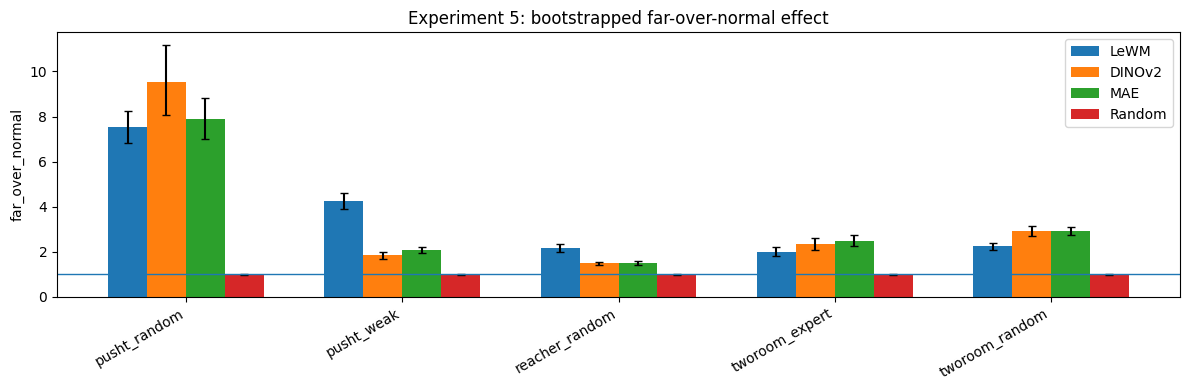

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_bootstrap_far_over_normal.png


In [44]:
# Plot bootstrapped far_over_normal CIs

metric = "far_over_normal"

plot_df = exp5_bootstrap_ci[exp5_bootstrap_ci["metric"] == metric].copy()

runs = plot_df["run_name"].unique()
models = ["LeWM", "DINOv2", "MAE", "Random"]

x = np.arange(len(runs))
width = 0.18

plt.figure(figsize=(12, 4))

for i, model in enumerate(models):
    sub = plot_df[plot_df["model"] == model].set_index("run_name").reindex(runs)

    means = sub["mean"].values
    lows = means - sub["ci_low"].values
    highs = sub["ci_high"].values - means

    plt.bar(
        x + (i - 1.5) * width,
        means,
        width,
        label=model,
        yerr=[lows, highs],
        capsize=3,
    )

plt.axhline(1.0, linewidth=1)
plt.xticks(x, runs, rotation=30, ha="right")
plt.ylabel("far_over_normal")
plt.title("Experiment 5: bootstrapped far-over-normal effect")
plt.legend()
plt.tight_layout()

out_path = AGG_DIR / "exp5_bootstrap_far_over_normal.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

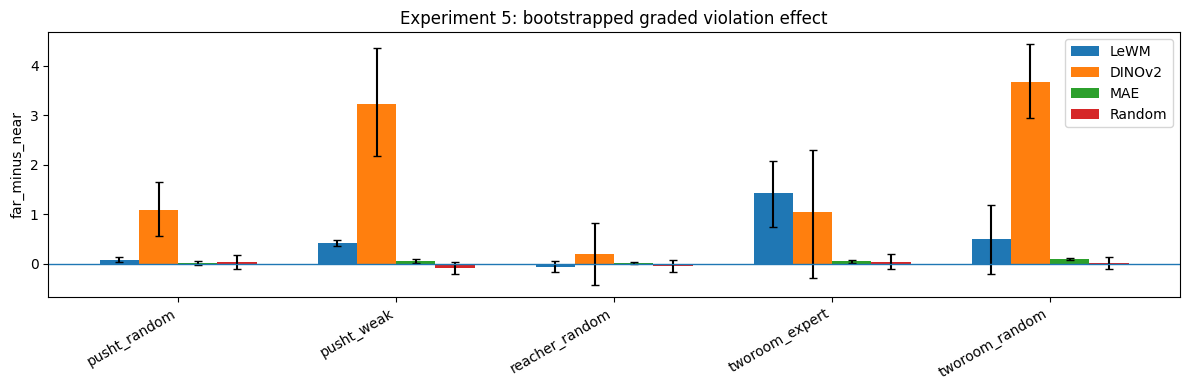

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_bootstrap_far_minus_near.png


In [45]:
# Plot bootstrapped far_minus_near CIs

metric = "far_minus_near"

plot_df = exp5_bootstrap_ci[exp5_bootstrap_ci["metric"] == metric].copy()

runs = plot_df["run_name"].unique()
models = ["LeWM", "DINOv2", "MAE", "Random"]

x = np.arange(len(runs))
width = 0.18

plt.figure(figsize=(12, 4))

for i, model in enumerate(models):
    sub = plot_df[plot_df["model"] == model].set_index("run_name").reindex(runs)

    means = sub["mean"].values
    lows = means - sub["ci_low"].values
    highs = sub["ci_high"].values - means

    plt.bar(
        x + (i - 1.5) * width,
        means,
        width,
        label=model,
        yerr=[lows, highs],
        capsize=3,
    )

plt.axhline(0.0, linewidth=1)
plt.xticks(x, runs, rotation=30, ha="right")
plt.ylabel("far_minus_near")
plt.title("Experiment 5: bootstrapped graded violation effect")
plt.legend()
plt.tight_layout()

out_path = AGG_DIR / "exp5_bootstrap_far_minus_near.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

In [46]:
# Phase 7.2 — Parameterized Exp 5 function for horizon / threshold sweeps

def run_experiment_5_voe_sweep(
    cfg,
    history_size=None,
    action_block=None,
    near_band=(45, 55),
    far_percentile=90,
    overwrite=False,
    tag=None,
):
    cfg_sweep = dict(cfg)

    if history_size is not None:
        cfg_sweep["history_size"] = history_size

    if action_block is not None:
        cfg_sweep["action_block"] = action_block

    if tag is None:
        tag = (
            f"H{cfg_sweep['history_size']}"
            f"_B{cfg_sweep['action_block']}"
            f"_near{near_band[0]}-{near_band[1]}"
            f"_far{far_percentile}"
        )

    dirs = make_run_dirs(cfg)

    summary_path = dirs["results"] / f"exp5_voe_summary_{tag}.csv"
    effects_path = dirs["results"] / f"exp5_voe_effects_{tag}.csv"

    if summary_path.exists() and effects_path.exists() and not overwrite:
        return pd.read_csv(summary_path), pd.read_csv(effects_path)

    states = np.load(dirs["data"] / "states.npy")
    T_run, E_run = states.shape[:2]

    reps = {
        "LeWM": np.load(dirs["latents"] / "lewm_z.npy").reshape(T_run, E_run, -1),
        "DINOv2": np.load(dirs["latents"] / "dino_z.npy").reshape(T_run, E_run, -1),
        "MAE": np.load(dirs["latents"] / "mae_z.npy").reshape(T_run, E_run, -1),
    }

    rng = np.random.default_rng(0)
    reps["Random"] = rng.normal(size=reps["LeWM"].shape).astype(np.float32)

    physical_features = get_voe_physical_features(cfg_sweep, dirs)

    summary_rows = []
    score_rows = []

    alphas = np.logspace(-4, 4, 17)

    for model_name, z_seq in reps.items():
        pack = build_prediction_windows(cfg_sweep, dirs, z_seq)

        emb_windows = pack["emb_windows"]
        act_windows = pack["act_windows"]
        targets = pack["targets"]
        target_indices = pack["target_indices"]
        target_times = pack["target_times"]

        if len(targets) < 20:
            raise RuntimeError(
                f"Too few valid prediction windows for {cfg['run_name']} / {model_name}: {len(targets)}"
            )

        Bn, H, D = emb_windows.shape

        X_lat = emb_windows.reshape(Bn, H * D)
        X_act = act_windows.reshape(Bn, -1)
        X = np.concatenate([X_lat, X_act], axis=1)
        y = targets

        cutoff = int(0.75 * cfg_sweep["T"])
        train_mask = target_times < cutoff
        test_mask = target_times >= cutoff

        if train_mask.sum() < 20 or test_mask.sum() < 20:
            idx = np.arange(Bn)
            train_idx, test_idx = train_test_split(
                idx,
                test_size=0.25,
                random_state=0,
                shuffle=True,
            )
        else:
            train_idx = np.where(train_mask)[0]
            test_idx = np.where(test_mask)[0]

        predictor = make_pipeline(
            StandardScaler(),
            RidgeCV(alphas=alphas),
        )

        print(f"Training Exp5 sweep: {cfg['run_name']} / {model_name} / {tag}")
        predictor.fit(X[train_idx], y[train_idx])
        pred = predictor.predict(X[test_idx])

        z_flat = z_seq.reshape(T_run * E_run, -1)

        cf = choose_counterfactual_targets_sweep(
            physical_features,
            target_indices,
            near_band=near_band,
            far_percentile=far_percentile,
            seed=123,
        )

        condition_targets = {
            "normal": targets,
            "near_violation": z_flat[cf["near"]],
            "far_violation": z_flat[cf["far"]],
            "random_target": z_flat[cf["random"]],
        }

        for condition, all_condition_targets in condition_targets.items():
            y_target = all_condition_targets[test_idx]
            surprise = np.linalg.norm(pred - y_target, axis=1)

            summary_rows.append({
                "run_name": cfg["run_name"],
                "env_key": cfg["env_key"],
                "policy_type": cfg["policy_type"],
                "model": model_name,
                "condition": condition,
                "mean_surprise": float(surprise.mean()),
                "std_surprise": float(surprise.std()),
                "median_surprise": float(np.median(surprise)),
                "num_windows": int(len(surprise)),
                "history_size": int(cfg_sweep["history_size"]),
                "action_block": int(cfg_sweep["action_block"]),
                "near_band": str(near_band),
                "far_percentile": int(far_percentile),
                "tag": tag,
            })

            for s in surprise:
                score_rows.append({
                    "run_name": cfg["run_name"],
                    "env_key": cfg["env_key"],
                    "policy_type": cfg["policy_type"],
                    "model": model_name,
                    "condition": condition,
                    "surprise": float(s),
                    "history_size": int(cfg_sweep["history_size"]),
                    "action_block": int(cfg_sweep["action_block"]),
                    "near_band": str(near_band),
                    "far_percentile": int(far_percentile),
                    "tag": tag,
                })

    summary_df = pd.DataFrame(summary_rows)
    scores_df = pd.DataFrame(score_rows)

    effects_rows = []

    for (run_name, model), sub in summary_df.groupby(["run_name", "model"]):
        vals = sub.set_index("condition")["mean_surprise"]

        normal = vals["normal"]
        near = vals["near_violation"]
        far = vals["far_violation"]
        random_t = vals["random_target"]

        effects_rows.append({
            "run_name": run_name,
            "env_key": cfg["env_key"],
            "policy_type": cfg["policy_type"],
            "model": model,
            "near_minus_normal": float(near - normal),
            "far_minus_normal": float(far - normal),
            "random_minus_normal": float(random_t - normal),
            "near_over_normal": float(near / normal),
            "far_over_normal": float(far / normal),
            "random_over_normal": float(random_t / normal),
            "far_minus_near": float(far - near),
            "far_minus_random": float(far - random_t),
            "history_size": int(cfg_sweep["history_size"]),
            "action_block": int(cfg_sweep["action_block"]),
            "near_band": str(near_band),
            "far_percentile": int(far_percentile),
            "tag": tag,
        })

    effects_df = pd.DataFrame(effects_rows)

    summary_df.to_csv(summary_path, index=False)
    scores_df.to_csv(dirs["results"] / f"exp5_voe_scores_{tag}.csv", index=False)
    effects_df.to_csv(effects_path, index=False)

    return summary_df, effects_df

In [47]:
def choose_counterfactual_targets_sweep(
    physical_features,
    target_indices,
    near_band=(45, 55),
    far_percentile=90,
    seed=123,
):
    physical = StandardScaler().fit_transform(physical_features)
    rng = np.random.default_rng(seed)

    near_indices = []
    far_indices = []
    random_indices = []

    N = physical.shape[0]

    for true_idx in target_indices:
        d = np.linalg.norm(physical - physical[true_idx], axis=1)
        d[true_idx] = np.inf

        finite = d[np.isfinite(d)]

        near_low, near_high = np.percentile(finite, near_band)
        near_pool = np.where((d >= near_low) & (d <= near_high))[0]

        far_thresh = np.percentile(finite, far_percentile)
        far_pool = np.where(d >= far_thresh)[0]

        near_indices.append(rng.choice(near_pool))
        far_indices.append(rng.choice(far_pool))

        r = rng.integers(0, N)
        while r == true_idx:
            r = rng.integers(0, N)
        random_indices.append(r)

    return {
        "near": np.asarray(near_indices),
        "far": np.asarray(far_indices),
        "random": np.asarray(random_indices),
    }

In [48]:
# Phase 7.2 — Horizon sweep

horizon_settings = [
    {"history_size": 2, "action_block": 5},
    {"history_size": 3, "action_block": 5},
    {"history_size": 4, "action_block": 5},
]

HORIZON_SWEEP_SUMMARIES = []
HORIZON_SWEEP_EFFECTS = []

for setting in horizon_settings:
    for cfg in SWEEP_CONFIGS:
        tag = f"horizon_H{setting['history_size']}_B{setting['action_block']}"

        summary_df, effects_df = run_experiment_5_voe_sweep(
            cfg,
            history_size=setting["history_size"],
            action_block=setting["action_block"],
            near_band=(45, 55),
            far_percentile=90,
            overwrite=False,
            tag=tag,
        )

        HORIZON_SWEEP_SUMMARIES.append(summary_df)
        HORIZON_SWEEP_EFFECTS.append(effects_df)

horizon_summary_all = pd.concat(HORIZON_SWEEP_SUMMARIES, ignore_index=True)
horizon_effects_all = pd.concat(HORIZON_SWEEP_EFFECTS, ignore_index=True)

horizon_summary_all.to_csv(AGG_DIR / "exp5_horizon_sweep_summary.csv", index=False)
horizon_effects_all.to_csv(AGG_DIR / "exp5_horizon_sweep_effects.csv", index=False)

display(horizon_effects_all)

print("Saved:")
print(AGG_DIR / "exp5_horizon_sweep_summary.csv")
print(AGG_DIR / "exp5_horizon_sweep_effects.csv")

Training Exp5 sweep: pusht_weak / LeWM / horizon_H2_B5
Training Exp5 sweep: pusht_weak / DINOv2 / horizon_H2_B5
Training Exp5 sweep: pusht_weak / MAE / horizon_H2_B5
Training Exp5 sweep: pusht_weak / Random / horizon_H2_B5
Training Exp5 sweep: pusht_random / LeWM / horizon_H2_B5
Training Exp5 sweep: pusht_random / DINOv2 / horizon_H2_B5
Training Exp5 sweep: pusht_random / MAE / horizon_H2_B5
Training Exp5 sweep: pusht_random / Random / horizon_H2_B5
Training Exp5 sweep: tworoom_expert / LeWM / horizon_H2_B5
Training Exp5 sweep: tworoom_expert / DINOv2 / horizon_H2_B5
Training Exp5 sweep: tworoom_expert / MAE / horizon_H2_B5
Training Exp5 sweep: tworoom_expert / Random / horizon_H2_B5
Training Exp5 sweep: tworoom_random / LeWM / horizon_H2_B5
Training Exp5 sweep: tworoom_random / DINOv2 / horizon_H2_B5
Training Exp5 sweep: tworoom_random / MAE / horizon_H2_B5
Training Exp5 sweep: tworoom_random / Random / horizon_H2_B5
Training Exp5 sweep: reacher_random / LeWM / horizon_H2_B5
Training 

,run_name,env_key,policy_type,model,near_minus_normal,far_minus_normal,random_minus_normal,near_over_normal,far_over_normal,random_over_normal,far_minus_near,far_minus_random,history_size,action_block,near_band,far_percentile,tag
0,pusht_weak,pusht,weak,DINOv2,4.925892,7.261429,5.240957,1.313215,1.461721,1.333248,2.335537,2.020472,2,5,"(45, 55)",90,horizon_H2_B5
1,pusht_weak,pusht,weak,LeWM,0.846464,1.206890,0.819608,2.702140,3.426914,2.648135,0.360426,0.387282,2,5,"(45, 55)",90,horizon_H2_B5
2,pusht_weak,pusht,weak,MAE,0.436375,0.486824,0.398281,1.728086,1.812259,1.664527,0.050449,0.088543,2,5,"(45, 55)",90,horizon_H2_B5
3,pusht_weak,pusht,weak,Random,0.033304,-0.159699,-0.084955,1.002389,0.988542,0.993905,-0.193003,-0.074744,2,5,"(45, 55)",90,horizon_H2_B5
4,pusht_random,pusht,random,DINOv2,13.750171,14.734307,12.533645,4.099528,4.321369,3.825302,0.984136,2.200661,2,5,"(45, 55)",90,horizon_H2_B5
5,pusht_random,pusht,random,LeWM,0.821405,0.961621,0.741795,5.267839,5.996369,4.854201,0.140216,0.219826,2,5,"(45, 55)",90,horizon_H2_B5
6,pusht_random,pusht,random,MAE,0.779183,0.825143,0.730895,4.920542,5.151794,4.677577,0.045960,0.094248,2,5,"(45, 55)",90,horizon_H2_B5
7,pusht_random,pusht,random,Random,-0.060972,-0.104776,-0.086285,0.995625,0.992482,0.993809,-0.043804,-0.018491,2,5,"(45, 55)",90,horizon_H2_B5
8,tworoom_expert,tworoom,expert,DINOv2,7.813449,7.673327,6.948445,1.965413,1.948100,1.858535,-0.140122,0.724883,2,5,"(45, 55)",90,horizon_H2_B5
9,tworoom_expert,tworoom,expert,LeWM,4.014778,5.709738,3.870131,1.537289,1.764121,1.517931,1.694960,1.839607,2,5,"(45, 55)",90,horizon_H2_B5


Saved:
/content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_horizon_sweep_summary.csv
/content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_horizon_sweep_effects.csv


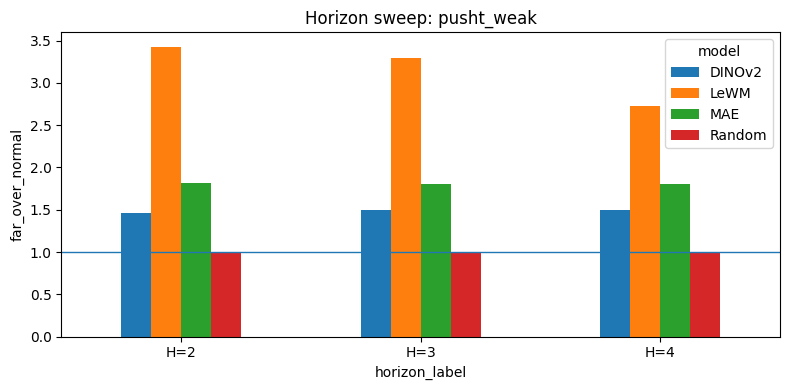

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_horizon_sweep_pusht_weak.png


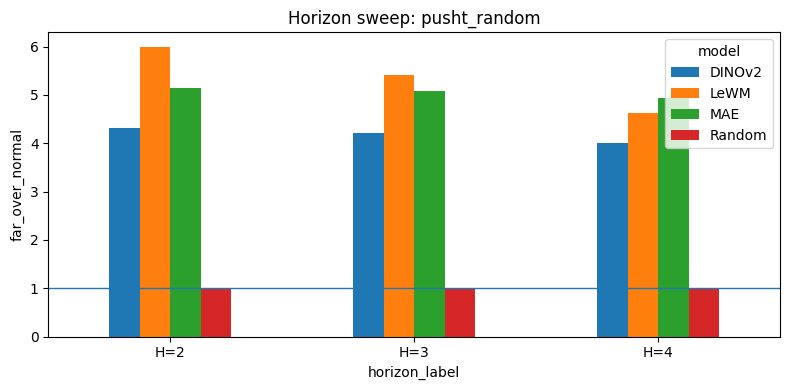

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_horizon_sweep_pusht_random.png


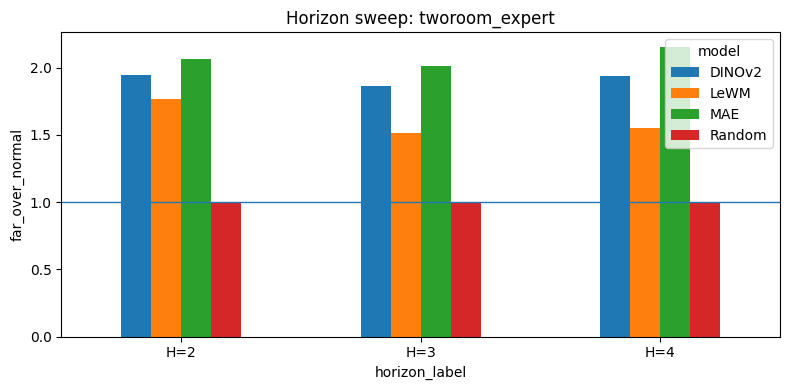

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_horizon_sweep_tworoom_expert.png


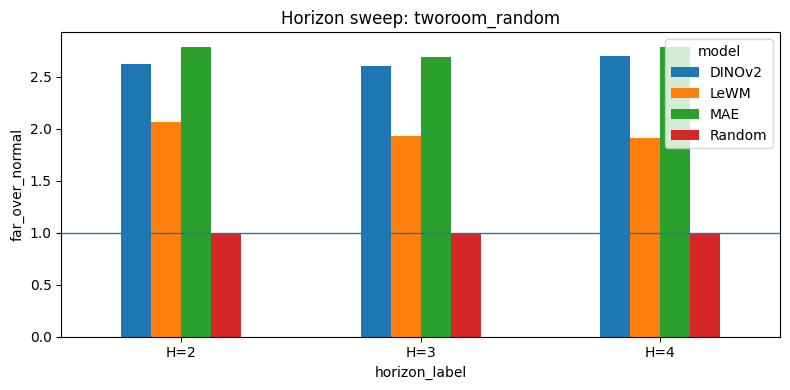

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_horizon_sweep_tworoom_random.png


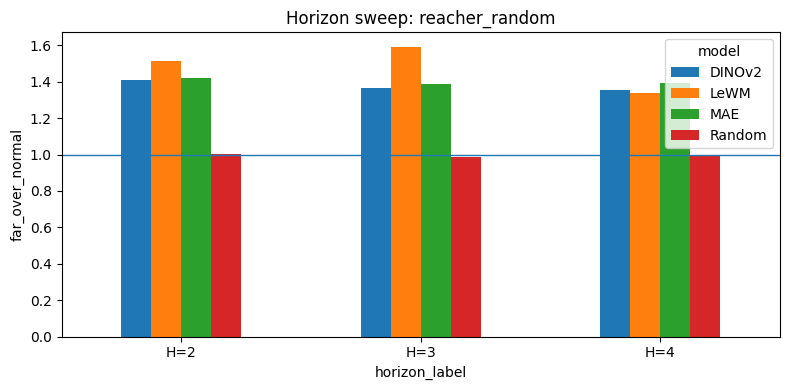

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_horizon_sweep_reacher_random.png


In [49]:
# Plot horizon sweep: far_over_normal

plot_df = horizon_effects_all.copy()
plot_df["horizon_label"] = "H=" + plot_df["history_size"].astype(str)

for run_name in plot_df["run_name"].unique():
    sub = plot_df[plot_df["run_name"] == run_name]

    pivot = sub.pivot_table(
        index="horizon_label",
        columns="model",
        values="far_over_normal",
    )

    ax = pivot.plot(kind="bar", figsize=(8, 4))
    ax.axhline(1.0, linewidth=1)
    ax.set_ylabel("far_over_normal")
    ax.set_title(f"Horizon sweep: {run_name}")
    plt.xticks(rotation=0)
    plt.tight_layout()

    out_path = AGG_DIR / f"exp5_horizon_sweep_{run_name}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()

    print("Saved:", out_path)

In [50]:
# Phase 7.3 — Threshold sweep

threshold_settings = [
    {"near_band": (40, 60), "far_percentile": 80},
    {"near_band": (40, 60), "far_percentile": 90},
    {"near_band": (45, 55), "far_percentile": 90},
    {"near_band": (45, 55), "far_percentile": 95},
]

THRESHOLD_SWEEP_SUMMARIES = []
THRESHOLD_SWEEP_EFFECTS = []

for setting in threshold_settings:
    for cfg in SWEEP_CONFIGS:
        tag = (
            f"threshold_near{setting['near_band'][0]}-{setting['near_band'][1]}"
            f"_far{setting['far_percentile']}"
        )

        summary_df, effects_df = run_experiment_5_voe_sweep(
            cfg,
            history_size=cfg["history_size"],
            action_block=cfg["action_block"],
            near_band=setting["near_band"],
            far_percentile=setting["far_percentile"],
            overwrite=False,
            tag=tag,
        )

        THRESHOLD_SWEEP_SUMMARIES.append(summary_df)
        THRESHOLD_SWEEP_EFFECTS.append(effects_df)

threshold_summary_all = pd.concat(THRESHOLD_SWEEP_SUMMARIES, ignore_index=True)
threshold_effects_all = pd.concat(THRESHOLD_SWEEP_EFFECTS, ignore_index=True)

threshold_summary_all.to_csv(AGG_DIR / "exp5_threshold_sweep_summary.csv", index=False)
threshold_effects_all.to_csv(AGG_DIR / "exp5_threshold_sweep_effects.csv", index=False)

display(threshold_effects_all)

print("Saved:")
print(AGG_DIR / "exp5_threshold_sweep_summary.csv")
print(AGG_DIR / "exp5_threshold_sweep_effects.csv")

Training Exp5 sweep: pusht_weak / LeWM / threshold_near40-60_far80
Training Exp5 sweep: pusht_weak / DINOv2 / threshold_near40-60_far80
Training Exp5 sweep: pusht_weak / MAE / threshold_near40-60_far80
Training Exp5 sweep: pusht_weak / Random / threshold_near40-60_far80
Training Exp5 sweep: pusht_random / LeWM / threshold_near40-60_far80
Training Exp5 sweep: pusht_random / DINOv2 / threshold_near40-60_far80
Training Exp5 sweep: pusht_random / MAE / threshold_near40-60_far80
Training Exp5 sweep: pusht_random / Random / threshold_near40-60_far80
Training Exp5 sweep: tworoom_expert / LeWM / threshold_near40-60_far80
Training Exp5 sweep: tworoom_expert / DINOv2 / threshold_near40-60_far80
Training Exp5 sweep: tworoom_expert / MAE / threshold_near40-60_far80
Training Exp5 sweep: tworoom_expert / Random / threshold_near40-60_far80
Training Exp5 sweep: tworoom_random / LeWM / threshold_near40-60_far80
Training Exp5 sweep: tworoom_random / DINOv2 / threshold_near40-60_far80
Training Exp5 sweep

,run_name,env_key,policy_type,model,near_minus_normal,far_minus_normal,random_minus_normal,near_over_normal,far_over_normal,random_over_normal,far_minus_near,far_minus_random,history_size,action_block,near_band,far_percentile,tag
0,pusht_weak,pusht,weak,DINOv2,5.110954,7.173613,4.962744,1.319473,1.448405,1.310209,2.062659,2.210869,3,5,"(40, 60)",80,threshold_near40-60_far80
1,pusht_weak,pusht,weak,LeWM,0.819404,1.138735,0.796494,2.553101,3.158361,2.509678,0.319330,0.342240,3,5,"(40, 60)",80,threshold_near40-60_far80
2,pusht_weak,pusht,weak,MAE,0.417603,0.460884,0.355493,1.709221,1.782726,1.603739,0.043281,0.105391,3,5,"(40, 60)",80,threshold_near40-60_far80
3,pusht_weak,pusht,weak,Random,-0.164265,-0.098504,-0.163177,0.988221,0.992936,0.988299,0.065760,0.064673,3,5,"(40, 60)",80,threshold_near40-60_far80
4,pusht_random,pusht,random,DINOv2,13.776755,14.626697,11.924062,3.979558,4.163379,3.578868,0.849941,2.702635,3,5,"(40, 60)",80,threshold_near40-60_far80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,tworoom_random,tworoom,random,Random,-0.112532,-0.041154,-0.161655,0.991929,0.997049,0.988406,0.071379,0.120502,3,5,"(45, 55)",95,threshold_near45-55_far95
76,reacher_random,reacher,random,DINOv2,4.524953,4.116087,4.145954,1.351476,1.319717,1.322037,-0.408866,-0.029867,3,5,"(45, 55)",95,threshold_near45-55_far95
77,reacher_random,reacher,random,LeWM,0.995209,0.785173,0.835960,1.629928,1.496984,1.529130,-0.210036,-0.050788,3,5,"(45, 55)",95,threshold_near45-55_far95
78,reacher_random,reacher,random,MAE,0.169582,0.154650,0.162323,1.365568,1.333378,1.349919,-0.014932,-0.007673,3,5,"(45, 55)",95,threshold_near45-55_far95


Saved:
/content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_threshold_sweep_summary.csv
/content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_threshold_sweep_effects.csv


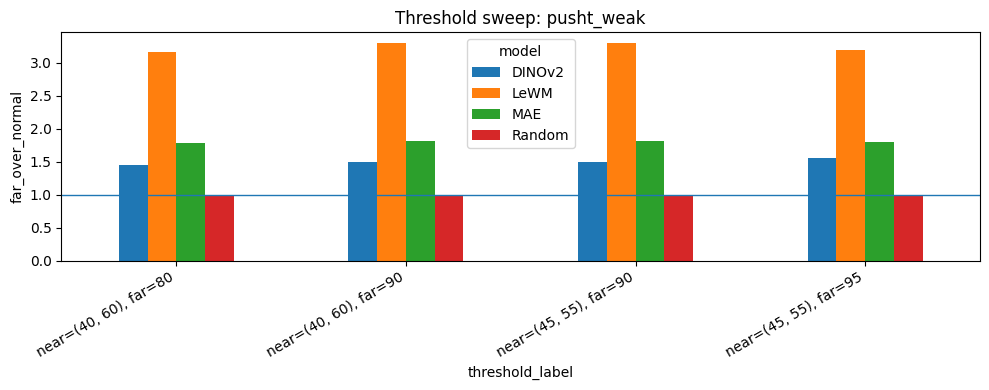

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_threshold_sweep_pusht_weak.png


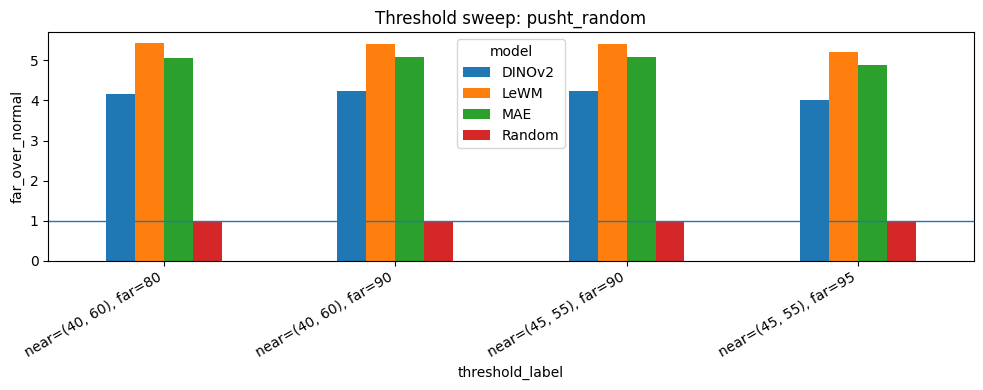

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_threshold_sweep_pusht_random.png


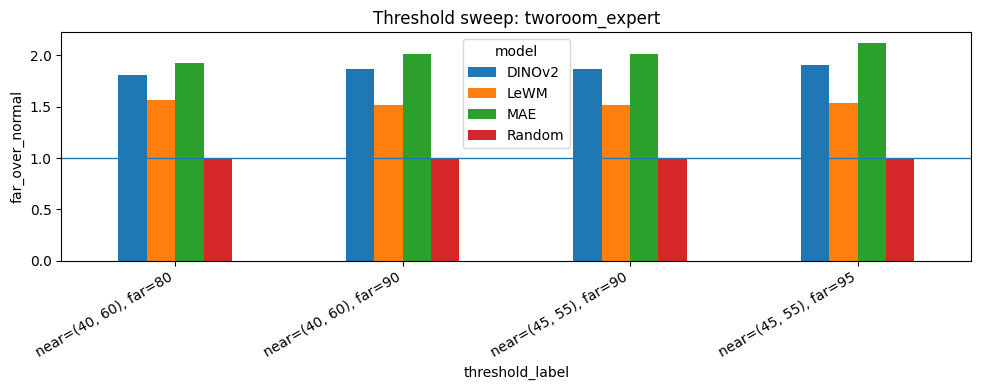

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_threshold_sweep_tworoom_expert.png


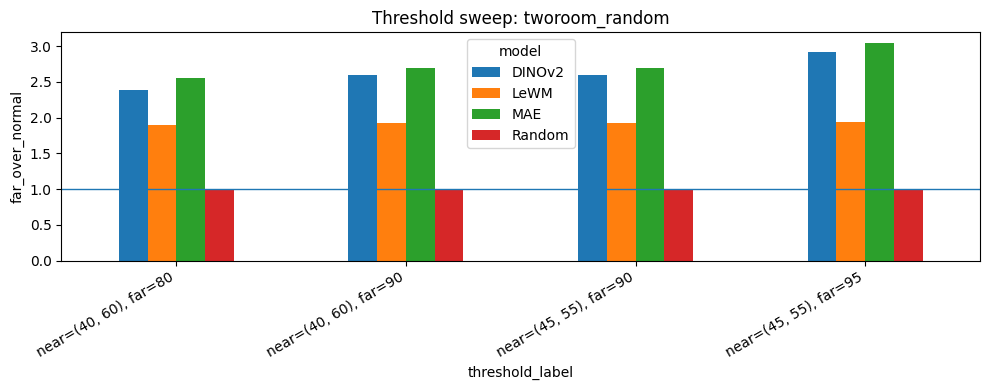

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_threshold_sweep_tworoom_random.png


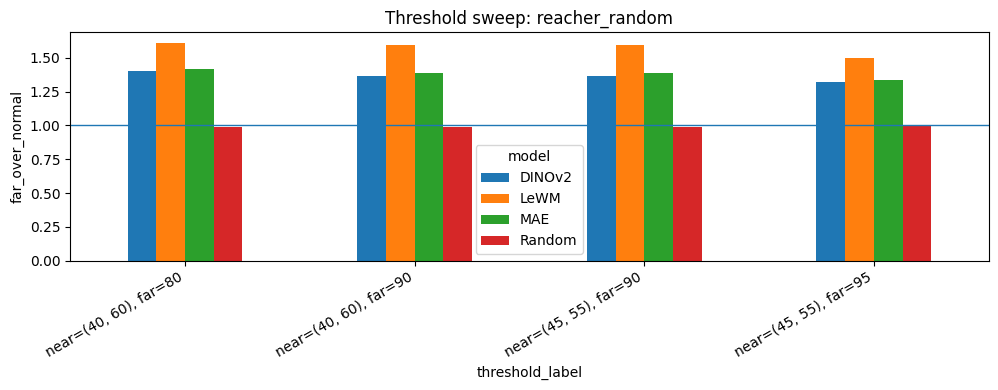

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_threshold_sweep_reacher_random.png


In [51]:
# Plot threshold sweep: far_over_normal per run

threshold_effects_all["threshold_label"] = (
    "near="
    + threshold_effects_all["near_band"].astype(str)
    + ", far="
    + threshold_effects_all["far_percentile"].astype(str)
)

for run_name in threshold_effects_all["run_name"].unique():
    sub = threshold_effects_all[threshold_effects_all["run_name"] == run_name]

    pivot = sub.pivot_table(
        index="threshold_label",
        columns="model",
        values="far_over_normal",
    )

    ax = pivot.plot(kind="bar", figsize=(10, 4))
    ax.axhline(1.0, linewidth=1)
    ax.set_ylabel("far_over_normal")
    ax.set_title(f"Threshold sweep: {run_name}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    out_path = AGG_DIR / f"exp5_threshold_sweep_{run_name}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()

    print("Saved:", out_path)

# Phase 8 — Controls

This phase tests whether the VoE effect is truly predictive / physical,
or just a byproduct of smoothness or latent distance.

We run two controls:

8.1 No-action predictor
    Remove actions and test whether prediction still works.

8.2 Latent-distance control
    Match targets by latent distance but vary physical distance.

Goal:
- Show VoE depends on dynamics + physical structure, not just distance.

In [52]:
# Phase 8.1 — No-action predictor

def run_experiment_5_no_action(cfg, overwrite=False):
    dirs = make_run_dirs(cfg)

    summary_path = dirs["results"] / "exp5_no_action_summary.csv"
    effects_path = dirs["results"] / "exp5_no_action_effects.csv"

    if summary_path.exists() and effects_path.exists() and not overwrite:
        return pd.read_csv(summary_path), pd.read_csv(effects_path)

    states = np.load(dirs["data"] / "states.npy")
    T_run, E_run = states.shape[:2]

    reps = {
        "LeWM": np.load(dirs["latents"] / "lewm_z.npy").reshape(T_run, E_run, -1),
        "DINOv2": np.load(dirs["latents"] / "dino_z.npy").reshape(T_run, E_run, -1),
        "MAE": np.load(dirs["latents"] / "mae_z.npy").reshape(T_run, E_run, -1),
    }

    rng = np.random.default_rng(0)
    reps["Random"] = rng.normal(size=reps["LeWM"].shape).astype(np.float32)

    physical_features = get_voe_physical_features(cfg, dirs)

    summary_rows = []
    effects_rows = []

    for model_name, z_seq in reps.items():
        pack = build_prediction_windows(cfg, dirs, z_seq)

        emb_windows = pack["emb_windows"]
        targets = pack["targets"]
        target_indices = pack["target_indices"]
        target_times = pack["target_times"]

        if len(targets) < 20:
            continue

        Bn, H, D = emb_windows.shape

        # ❗ NO ACTIONS
        X = emb_windows.reshape(Bn, H * D)
        y = targets

        idx = np.arange(Bn)
        train_idx, test_idx = train_test_split(
            idx, test_size=0.25, random_state=0
        )

        predictor = make_pipeline(
            StandardScaler(),
            RidgeCV(alphas=np.logspace(-4, 4, 17)),
        )

        predictor.fit(X[train_idx], y[train_idx])
        pred = predictor.predict(X[test_idx])

        z_flat = z_seq.reshape(T_run * E_run, -1)

        cf = choose_counterfactual_targets(
            physical_features,
            target_indices,
            seed=123,
        )

        condition_targets = {
            "normal": targets,
            "near": z_flat[cf["near"]],
            "far": z_flat[cf["far"]],
            "random": z_flat[cf["random"]],
        }

        vals = {}
        for cond, tgt in condition_targets.items():
            surprise = np.linalg.norm(pred - tgt[test_idx], axis=1)
            vals[cond] = surprise.mean()

        effects_rows.append({
            "run_name": cfg["run_name"],
            "model": model_name,
            "near_minus_normal": vals["near"] - vals["normal"],
            "far_minus_normal": vals["far"] - vals["normal"],
            "far_over_normal": vals["far"] / vals["normal"],
        })

    effects_df = pd.DataFrame(effects_rows)
    effects_df.to_csv(effects_path, index=False)

    return effects_df

In [53]:
NO_ACTION_RESULTS = []

for cfg in SWEEP_CONFIGS:
    df = run_experiment_5_no_action(cfg, overwrite=False)
    df["run_name"] = cfg["run_name"]
    NO_ACTION_RESULTS.append(df)

no_action_all = pd.concat(NO_ACTION_RESULTS, ignore_index=True)
display(no_action_all)

,run_name,model,near_minus_normal,far_minus_normal,far_over_normal
0,pusht_weak,LeWM,1.082662,1.421733,6.151567
1,pusht_weak,DINOv2,12.230209,14.547283,2.422923
2,pusht_weak,MAE,0.667713,0.685343,2.807304
3,pusht_weak,Random,0.010826,-0.158538,0.988588
4,pusht_random,LeWM,0.815992,0.946437,5.418909
5,pusht_random,DINOv2,14.218947,15.109244,4.482997
6,pusht_random,MAE,0.761640,0.825327,4.766146
7,pusht_random,Random,0.016618,-0.054992,0.996041
8,tworoom_expert,LeWM,4.242073,6.420865,2.017999
9,tworoom_expert,DINOv2,7.201694,7.384323,1.876996


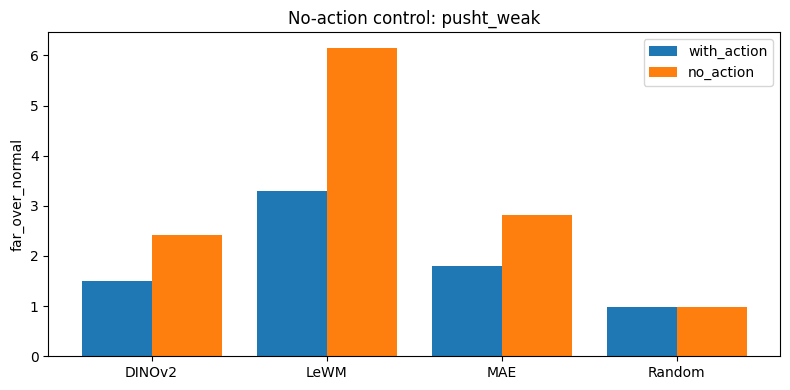

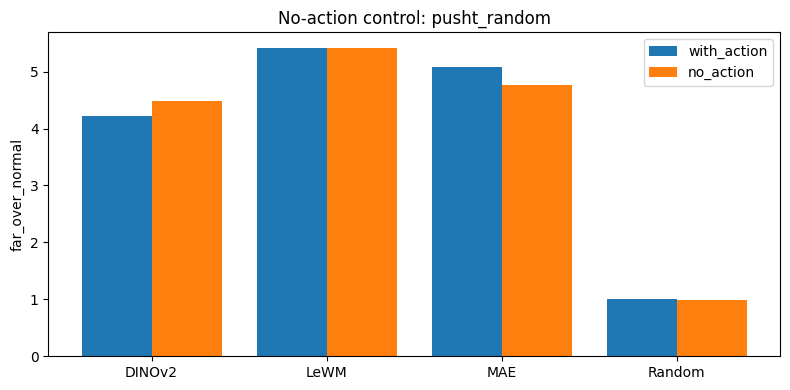

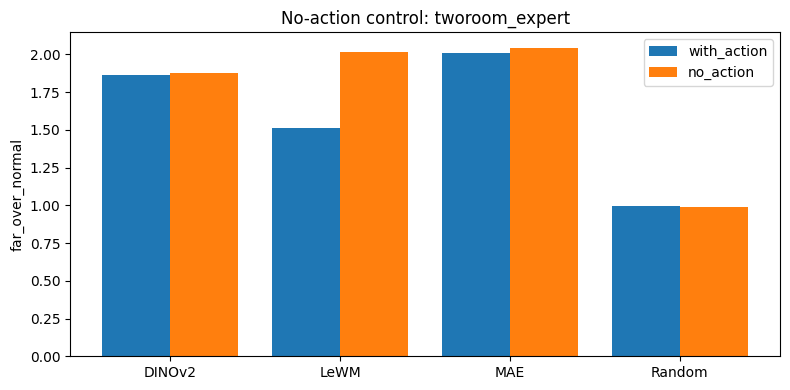

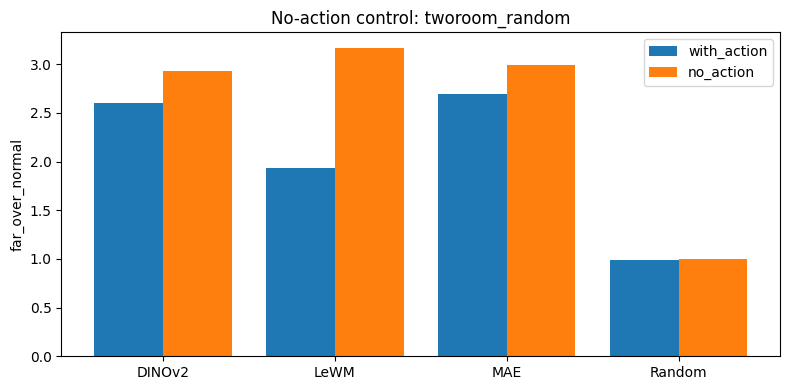

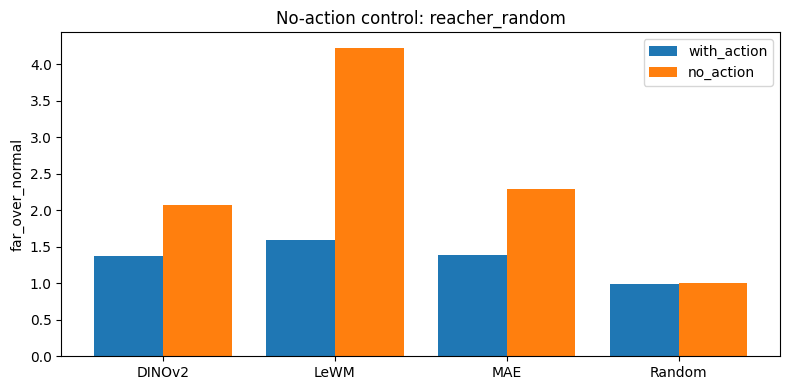

In [54]:
# Compare WITH vs WITHOUT actions

merged = exp5_effects_all.merge(
    no_action_all,
    on=["run_name", "model"],
    suffixes=("_with_action", "_no_action"),
)

for run in merged["run_name"].unique():
    sub = merged[merged["run_name"] == run]

    plt.figure(figsize=(8,4))
    x = np.arange(len(sub))

    plt.bar(x - 0.2, sub["far_over_normal_with_action"], 0.4, label="with_action")
    plt.bar(x + 0.2, sub["far_over_normal_no_action"], 0.4, label="no_action")

    plt.xticks(x, sub["model"])
    plt.title(f"No-action control: {run}")
    plt.ylabel("far_over_normal")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [55]:
# Phase 8.2 — Latent-distance control

def choose_counterfactual_targets_latent_control(
    z_flat,
    physical_features,
    target_indices,
    seed=0,
):
    z_norm = StandardScaler().fit_transform(z_flat)
    phys_norm = StandardScaler().fit_transform(physical_features)

    rng = np.random.default_rng(seed)

    near_phys = []
    far_phys = []
    matched_latent = []

    for idx in target_indices:
        dz = np.linalg.norm(z_norm - z_norm[idx], axis=1)
        dp = np.linalg.norm(phys_norm - phys_norm[idx], axis=1)

        dz[idx] = np.inf
        dp[idx] = np.inf

        # Step 1: pick latent-distance band
        low, high = np.percentile(dz[np.isfinite(dz)], [40, 60])
        latent_band = np.where((dz >= low) & (dz <= high))[0]

        # Step 2: within same latent band, split by physical distance
        phys_vals = dp[latent_band]

        phys_low, phys_high = np.percentile(phys_vals, [40, 90])

        near_pool = latent_band[phys_vals <= phys_low]
        far_pool = latent_band[phys_vals >= phys_high]

        near_phys.append(rng.choice(near_pool))
        far_phys.append(rng.choice(far_pool))
        matched_latent.append(rng.choice(latent_band))

    return {
        "near_phys": np.array(near_phys),
        "far_phys": np.array(far_phys),
        "latent_match": np.array(matched_latent),
    }

In [56]:
def run_experiment_5_latent_control(cfg, overwrite=False):
    dirs = make_run_dirs(cfg)

    states = np.load(dirs["data"] / "states.npy")
    T_run, E_run = states.shape[:2]

    reps = {
        "LeWM": np.load(dirs["latents"] / "lewm_z.npy").reshape(T_run, E_run, -1),
        "DINOv2": np.load(dirs["latents"] / "dino_z.npy").reshape(T_run, E_run, -1),
        "MAE": np.load(dirs["latents"] / "mae_z.npy").reshape(T_run, E_run, -1),
    }

    physical_features = get_voe_physical_features(cfg, dirs)

    rows = []

    for model_name, z_seq in reps.items():
        pack = build_prediction_windows(cfg, dirs, z_seq)

        emb_windows = pack["emb_windows"]
        act_windows = pack["act_windows"]
        targets = pack["targets"]
        target_indices = pack["target_indices"]

        Bn, H, D = emb_windows.shape

        X = np.concatenate([
            emb_windows.reshape(Bn, H * D),
            act_windows.reshape(Bn, -1),
        ], axis=1)

        y = targets

        train_idx, test_idx = train_test_split(
            np.arange(Bn), test_size=0.25, random_state=0
        )

        predictor = make_pipeline(
            StandardScaler(),
            RidgeCV(alphas=np.logspace(-4,4,17)),
        )

        predictor.fit(X[train_idx], y[train_idx])
        pred = predictor.predict(X[test_idx])

        z_flat = z_seq.reshape(T_run * E_run, -1)

        cf = choose_counterfactual_targets_latent_control(
            z_flat,
            physical_features,
            target_indices,
        )

        conds = {
            "near_phys": z_flat[cf["near_phys"]],
            "far_phys": z_flat[cf["far_phys"]],
            "latent_match": z_flat[cf["latent_match"]],
        }

        for cond, tgt in conds.items():
            surprise = np.linalg.norm(pred - tgt[test_idx], axis=1)

            rows.append({
                "run_name": cfg["run_name"],
                "model": model_name,
                "condition": cond,
                "mean_surprise": float(surprise.mean()),
            })

    return pd.DataFrame(rows)

In [57]:
LATENT_CTRL_RESULTS = []

for cfg in SWEEP_CONFIGS:
    df = run_experiment_5_latent_control(cfg)
    LATENT_CTRL_RESULTS.append(df)

latent_ctrl_all = pd.concat(LATENT_CTRL_RESULTS, ignore_index=True)
display(latent_ctrl_all)

,run_name,model,condition,mean_surprise
0,pusht_weak,LeWM,near_phys,1.342658
1,pusht_weak,LeWM,far_phys,1.428080
2,pusht_weak,LeWM,latent_match,1.359588
3,pusht_weak,DINOv2,near_phys,21.206268
4,pusht_weak,DINOv2,far_phys,21.464416
5,pusht_weak,DINOv2,latent_match,21.207412
6,pusht_weak,MAE,near_phys,0.992593
7,pusht_weak,MAE,far_phys,0.980812
8,pusht_weak,MAE,latent_match,0.963172
9,pusht_random,LeWM,near_phys,0.993754


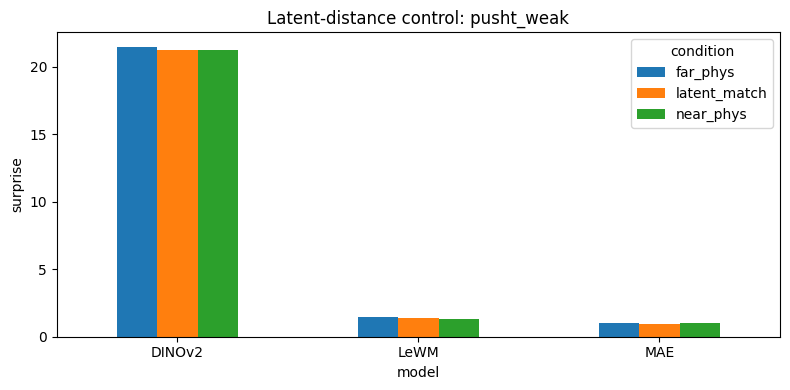

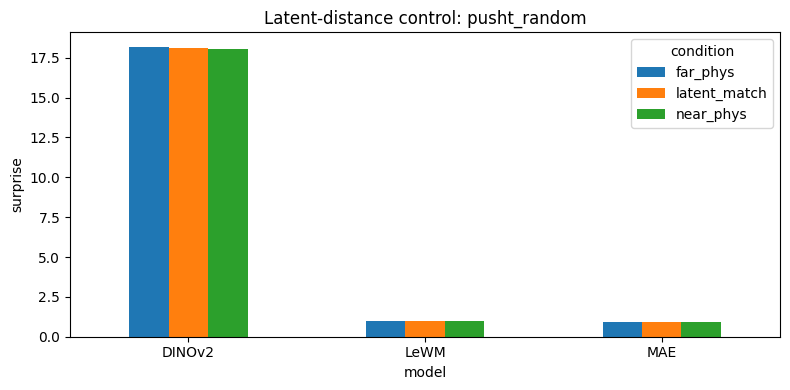

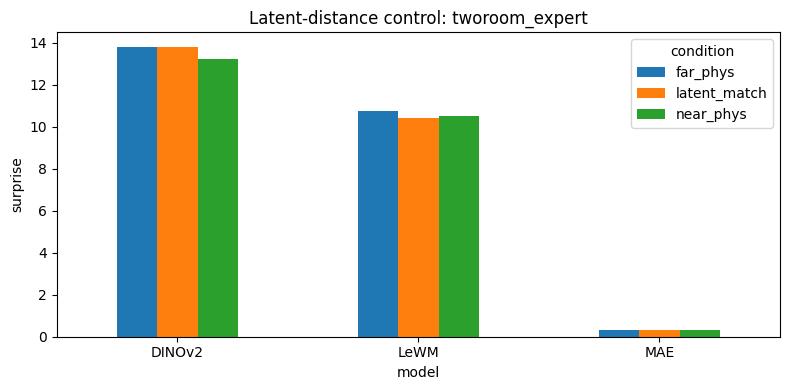

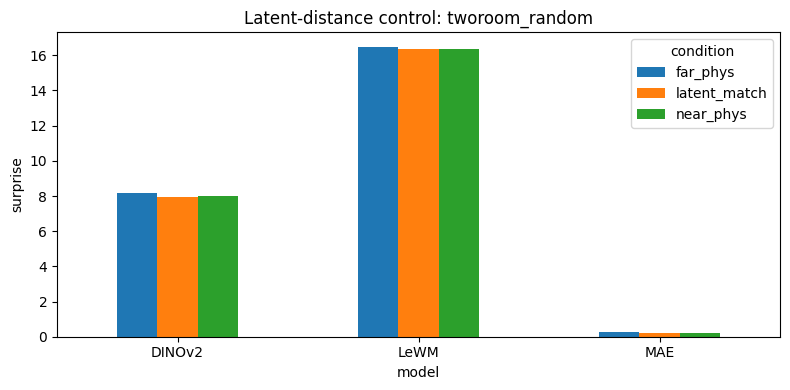

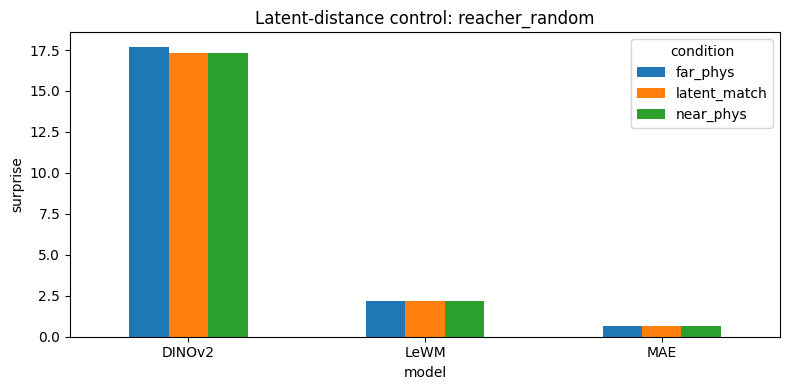

In [58]:
for run in latent_ctrl_all["run_name"].unique():
    sub = latent_ctrl_all[latent_ctrl_all["run_name"] == run]

    pivot = sub.pivot(index="model", columns="condition", values="mean_surprise")

    pivot.plot(kind="bar", figsize=(8,4))
    plt.title(f"Latent-distance control: {run}")
    plt.ylabel("surprise")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Phase 8.3 — Shuffled-Action Control

This control tests whether transition prediction actually depends on actions.

We train the same matched predictor using correct action histories, then evaluate on the same latent histories and targets under:

1. correct action histories
2. shuffled action histories

If the representation supports action-conditioned prediction, shuffling actions should increase normal prediction error.

In [59]:
def run_experiment_5_action_shuffle_control(cfg, overwrite=False, seed=0):
    dirs = make_run_dirs(cfg)

    out_path = dirs["results"] / "exp5_action_shuffle_control.csv"

    if out_path.exists() and not overwrite:
        return pd.read_csv(out_path)

    states = np.load(dirs["data"] / "states.npy")
    T_run, E_run = states.shape[:2]

    reps = {
        "LeWM": np.load(dirs["latents"] / "lewm_z.npy").reshape(T_run, E_run, -1),
        "DINOv2": np.load(dirs["latents"] / "dino_z.npy").reshape(T_run, E_run, -1),
        "MAE": np.load(dirs["latents"] / "mae_z.npy").reshape(T_run, E_run, -1),
    }

    rng = np.random.default_rng(seed)
    reps["Random"] = rng.normal(size=reps["LeWM"].shape).astype(np.float32)

    rows = []
    alphas = np.logspace(-4, 4, 17)

    for model_name, z_seq in reps.items():
        pack = build_prediction_windows(cfg, dirs, z_seq)

        emb_windows = pack["emb_windows"]
        act_windows = pack["act_windows"]
        targets = pack["targets"]
        target_times = pack["target_times"]

        if len(targets) < 20:
            raise RuntimeError(
                f"Too few valid prediction windows for {cfg['run_name']} / {model_name}: {len(targets)}"
            )

        Bn, H, D = emb_windows.shape

        X_lat = emb_windows.reshape(Bn, H * D)
        X_act = act_windows.reshape(Bn, -1)
        X = np.concatenate([X_lat, X_act], axis=1)
        y = targets

        cutoff = int(0.75 * cfg["T"])
        train_mask = target_times < cutoff
        test_mask = target_times >= cutoff

        if train_mask.sum() < 20 or test_mask.sum() < 20:
            idx = np.arange(Bn)
            train_idx, test_idx = train_test_split(
                idx,
                test_size=0.25,
                random_state=0,
                shuffle=True,
            )
        else:
            train_idx = np.where(train_mask)[0]
            test_idx = np.where(test_mask)[0]

        predictor = make_pipeline(
            StandardScaler(),
            RidgeCV(alphas=alphas),
        )

        predictor.fit(X[train_idx], y[train_idx])

        # Correct-action evaluation
        pred_correct = predictor.predict(X[test_idx])
        err_correct = np.linalg.norm(pred_correct - y[test_idx], axis=1)

        # Shuffled-action evaluation
        rng_model = np.random.default_rng(seed + hash(model_name) % 10_000)
        shuffled_test_idx = test_idx.copy()
        shuffled_order = rng_model.permutation(len(test_idx))

        X_act_test = X_act[test_idx]
        X_act_shuffled = X_act_test[shuffled_order]

        X_shuffled = np.concatenate(
            [
                X_lat[test_idx],
                X_act_shuffled,
            ],
            axis=1,
        )

        pred_shuffled = predictor.predict(X_shuffled)
        err_shuffled = np.linalg.norm(pred_shuffled - y[test_idx], axis=1)

        rows.append({
            "run_name": cfg["run_name"],
            "env_key": cfg["env_key"],
            "policy_type": cfg["policy_type"],
            "model": model_name,
            "correct_action_error_mean": float(err_correct.mean()),
            "correct_action_error_std": float(err_correct.std()),
            "shuffled_action_error_mean": float(err_shuffled.mean()),
            "shuffled_action_error_std": float(err_shuffled.std()),
            "shuffle_penalty": float(err_shuffled.mean() - err_correct.mean()),
            "shuffle_over_correct": float(err_shuffled.mean() / err_correct.mean()),
            "num_test_windows": int(len(test_idx)),
        })

    df = pd.DataFrame(rows)
    df.to_csv(out_path, index=False)

    save_json(
        dirs["results"] / "exp5_action_shuffle_control.json",
        {
            "config": cfg,
            "results": df.to_dict(orient="records"),
        },
    )

    return df

In [60]:
ACTION_SHUFFLE_RESULTS = []

for cfg in SWEEP_CONFIGS:
    df = run_experiment_5_action_shuffle_control(cfg, overwrite=False)
    ACTION_SHUFFLE_RESULTS.append(df)

    print("\nDONE:", cfg["run_name"])
    display(df)

action_shuffle_all = pd.concat(ACTION_SHUFFLE_RESULTS, ignore_index=True)

action_shuffle_all.to_csv(
    AGG_DIR / "exp5_action_shuffle_control_all.csv",
    index=False,
)

print("Saved:", AGG_DIR / "exp5_action_shuffle_control_all.csv")


DONE: pusht_weak


,run_name,env_key,policy_type,model,correct_action_error_mean,correct_action_error_std,shuffled_action_error_mean,shuffled_action_error_std,shuffle_penalty,shuffle_over_correct,num_test_windows
0,pusht_weak,pusht,weak,LeWM,0.527592,0.264631,0.555019,0.266656,0.027427,1.051985,192
1,pusht_weak,pusht,weak,DINOv2,15.998084,7.121532,16.018844,7.121703,0.020760,1.001298,192
2,pusht_weak,pusht,weak,MAE,0.588819,0.217718,0.589461,0.216953,0.000642,1.001091,192
3,pusht_weak,pusht,weak,Random,13.945022,0.649091,13.943746,0.648875,-0.001277,0.999908,192



DONE: pusht_random


,run_name,env_key,policy_type,model,correct_action_error_mean,correct_action_error_std,shuffled_action_error_mean,shuffled_action_error_std,shuffle_penalty,shuffle_over_correct,num_test_windows
0,pusht_random,pusht,random,LeWM,0.209405,0.123717,0.216798,0.130835,0.007392,1.035302,192
1,pusht_random,pusht,random,DINOv2,4.623758,2.918764,4.622621,2.928243,-0.001137,0.999754,192
2,pusht_random,pusht,random,MAE,0.204761,0.126554,0.202902,0.124078,-0.001859,0.990922,192
3,pusht_random,pusht,random,Random,13.943607,0.647193,13.944545,0.648831,0.000938,1.000067,192



DONE: tworoom_expert


...


DONE: tworoom_random


,run_name,env_key,policy_type,model,correct_action_error_mean,correct_action_error_std,shuffled_action_error_mean,shuffled_action_error_std,shuffle_penalty,shuffle_over_correct,num_test_windows
0,tworoom_random,tworoom,random,LeWM,9.646626,3.511830,10.150208,3.522603,0.503581,1.052203,192
1,tworoom_random,tworoom,random,DINOv2,4.649841,1.858644,4.848898,2.046136,0.199058,1.042810,192
2,tworoom_random,tworoom,random,MAE,0.124016,0.045508,0.128914,0.047541,0.004899,1.039499,192
3,tworoom_random,tworoom,random,Random,13.943607,0.647193,13.944545,0.648831,0.000938,1.000067,192



DONE: reacher_random


,run_name,env_key,policy_type,model,correct_action_error_mean,correct_action_error_std,shuffled_action_error_mean,shuffled_action_error_std,shuffle_penalty,shuffle_over_correct,num_test_windows
0,reacher_random,reacher,random,LeWM,1.579877,0.963884,1.592296,0.942658,0.012419,1.007861,192
1,reacher_random,reacher,random,DINOv2,12.874164,3.828457,12.917822,3.829324,0.043658,1.003391,192
2,reacher_random,reacher,random,MAE,0.463887,0.127478,0.465468,0.126472,0.001581,1.003408,192
3,reacher_random,reacher,random,Random,13.943607,0.647193,13.944545,0.648831,0.000938,1.000067,192


Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_action_shuffle_control_all.csv


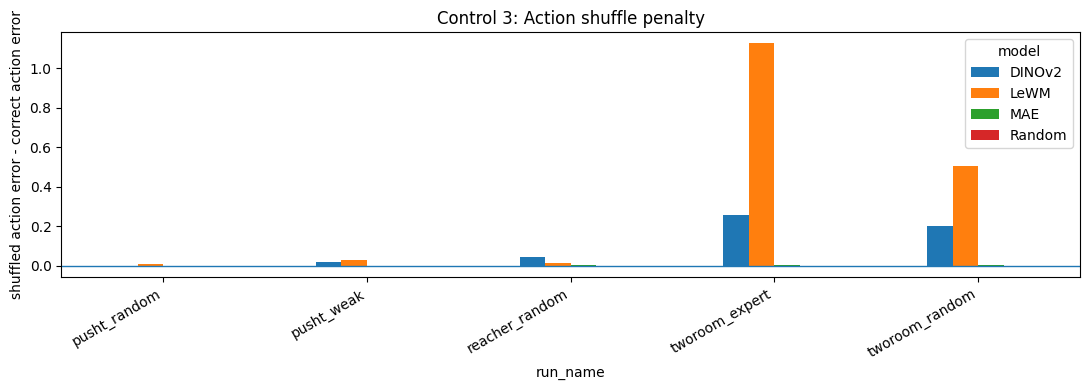

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_action_shuffle_penalty.png


In [61]:
plot_df = action_shuffle_all.pivot(
    index="run_name",
    columns="model",
    values="shuffle_penalty",
)

ax = plot_df.plot(kind="bar", figsize=(11, 4))
ax.axhline(0.0, linewidth=1)
ax.set_ylabel("shuffled action error - correct action error")
ax.set_title("Control 3: Action shuffle penalty")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

out_path = AGG_DIR / "exp5_action_shuffle_penalty.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

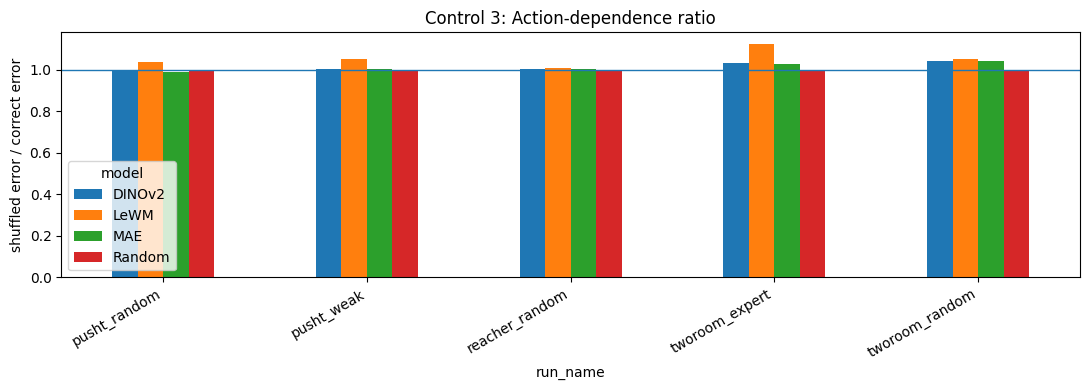

Saved: /content/drive/MyDrive/stablewm_sweep_project/aggregate/exp5_action_shuffle_ratio.png


In [62]:
plot_df = action_shuffle_all.pivot(
    index="run_name",
    columns="model",
    values="shuffle_over_correct",
)

ax = plot_df.plot(kind="bar", figsize=(11, 4))
ax.axhline(1.0, linewidth=1)
ax.set_ylabel("shuffled error / correct error")
ax.set_title("Control 3: Action-dependence ratio")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

out_path = AGG_DIR / "exp5_action_shuffle_ratio.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

# FINAL FIGURE DESIGN

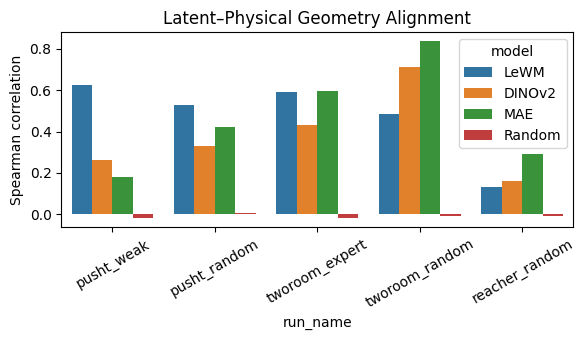

In [75]:
# Phase 9.1 — Geometry summary figure

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

geom = pd.read_csv(AGG_DIR / "exp3_all_geometry_results.csv")

plt.figure(figsize=(6, 3.5))
sns.barplot(
    data=geom[geom["target"] == "full_state"],
    x="run_name",
    y="spearman",
    hue="model"
)
plt.title("Latent–Physical Geometry Alignment")
plt.ylabel("Spearman correlation")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "paper_fig1_geometry.pdf")
plt.show()

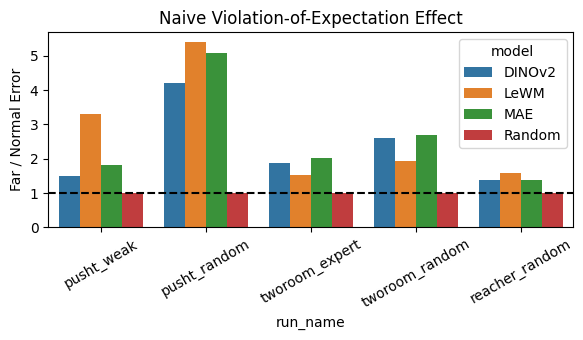

In [76]:
# Phase 9.2 — Naive VoE figure

voe = pd.read_csv(AGG_DIR / "exp5_all_voe_effects.csv")

effects = voe[["run_name", "model", "far_over_normal"]]

plt.figure(figsize=(6, 3.5))
sns.barplot(
    data=effects,
    x="run_name",
    y="far_over_normal",
    hue="model"
)
plt.axhline(1.0, linestyle="--", color="black")
plt.title("Naive Violation-of-Expectation Effect")
plt.ylabel("Far / Normal Error")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "paper_fig2_naive_voe.pdf")
plt.show()

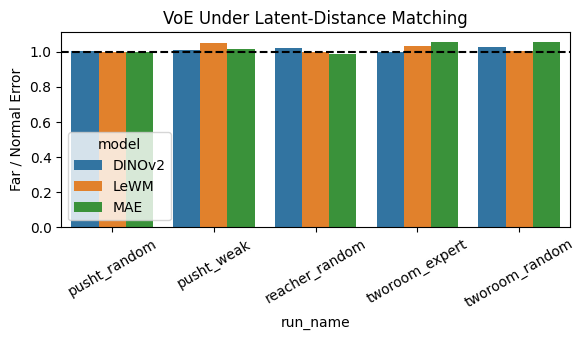

In [77]:
# Phase 9.3 — Latent distance control

# Calculate far_over_normal directly from the in-memory variable
ctrl_piv = latent_ctrl_all.pivot(
    index=["run_name", "model"],
    columns="condition",
    values="mean_surprise"
).reset_index()
ctrl_piv["far_over_normal"] = ctrl_piv["far_phys"] / ctrl_piv["latent_match"]
ctrl = ctrl_piv

plt.figure(figsize=(6, 3.5))
sns.barplot(
    data=ctrl,
    x="run_name",
    y="far_over_normal",
    hue="model"
)
plt.axhline(1.0, linestyle="--", color="black")
plt.title("VoE Under Latent-Distance Matching")
plt.ylabel("Far / Normal Error")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "paper_fig3_latent_control.pdf")
plt.show()

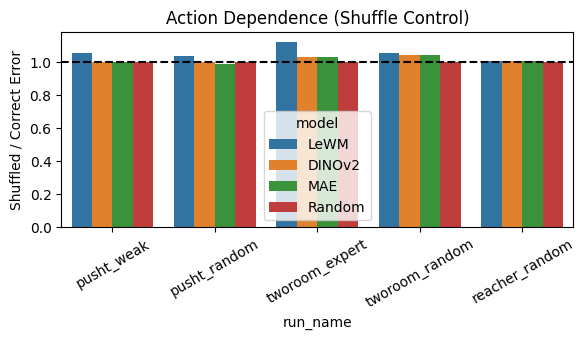

In [72]:
# Phase 9.4 — Action dependence figure

act = pd.read_csv(AGG_DIR / "exp5_action_shuffle_control_all.csv")

plt.figure(figsize=(6, 3.5))
sns.barplot(
    data=act,
    x="run_name",
    y="shuffle_over_correct",
    hue="model"
)
plt.axhline(1.0, linestyle="--", color="black")
plt.title("Action Dependence (Shuffle Control)")
plt.ylabel("Shuffled / Correct Error")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "paper_fig4_action_dependence.pdf")
plt.show()

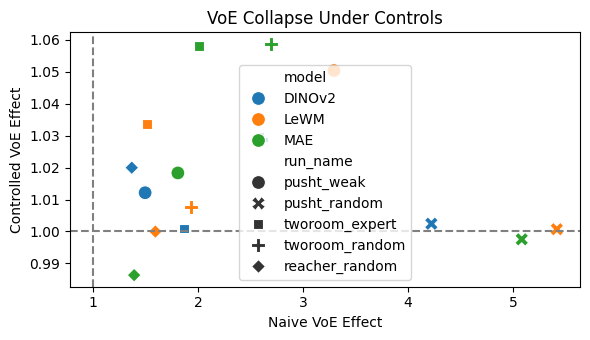

In [73]:
# Phase 9.5 — Summary comparison

summary = pd.merge(
    effects,
    ctrl,
    on=["run_name", "model"],
    suffixes=("_voe", "_ctrl")
)

plt.figure(figsize=(6, 3.5))
sns.scatterplot(
    data=summary,
    x="far_over_normal_voe",
    y="far_over_normal_ctrl",
    hue="model",
    style="run_name",
    s=100
)

plt.axhline(1.0, linestyle="--", color="gray")
plt.axvline(1.0, linestyle="--", color="gray")

plt.xlabel("Naive VoE Effect")
plt.ylabel("Controlled VoE Effect")
plt.title("VoE Collapse Under Controls")
plt.tight_layout()
plt.savefig(PROJECT_DIR / "paper_fig5_summary.pdf")
plt.show()

In [74]:
# Phase 9.6 — Table for paper

# Merge act to ensure shuffle_over_correct is available
summary_final = pd.merge(summary, act[["run_name", "model", "shuffle_over_correct"]], on=["run_name", "model"])

table = summary_final.groupby("model")[[
    "far_over_normal_voe",
    "far_over_normal_ctrl",
    "shuffle_over_correct"
]].mean()

table.to_csv(PROJECT_DIR / "paper_table_main.csv")
display(table)

,far_over_normal_voe,far_over_normal_ctrl,shuffle_over_correct
model,,,
DINOv2,2.309730,1.012862,1.015471
LeWM,2.750034,1.018462,1.054155
MAE,2.596479,1.023791,1.012765
